# Advanced DDoS Detection Pipeline
**CIC-DDoS2019 Dataset — Modular ML + DL Training Pipeline**

This notebook runs the full training pipeline end-to-end in 10 clear steps:

| Step | Description | Status |
|------|-------------|--------|
| 1 | Environment Setup | Clone repo & install deps |
| 2 | Download Dataset | Fetch from Kaggle |
| 3 | Data Inspection | Shape, types, missing values |
| 4 | Exploratory Data Analysis | 12 advanced visualizations |
| 5 | Data Preprocessing | Clean, split, scale, balance |
| 6 | Train ML Models | 7 models with hyperparameter tuning |
| 7 | Train DL Models | MLP, LSTM, CNN1D |
| 8 | Ensemble Learning | Voting & Stacking ensembles |
| 9 | Model Comparison | Summary table, confusion matrices, curves |
| 10 | Save All Models | Persist to disk with metadata |

Each step prints clear progress so you always know what is running and how much is left.

---
## Step 1 / 10 — Environment Setup

In [1]:
%%time
print("="*60)
print("  STEP 1/10 — Environment Setup")
print("="*60)

# Clone the repository
!git clone https://github.com/ahdabalboudi/sares.git /content/sares 2>/dev/null || \
    (cd /content/sares && git pull)

# Install dependencies
%pip install -q -r /content/sares/advanced_ddos_detection/requirements.txt

print("\n" + "✅ Step 1/10 complete — environment ready.")

  STEP 1/10 — Environment Setup
Already up to date.

✅ Step 1/10 complete — environment ready.
CPU times: user 1.43 s, sys: 218 ms, total: 1.65 s
Wall time: 7.67 s


---
## Step 2 / 10 — Download Dataset from Kaggle

In [2]:
%%time
import os
print("="*60)
print("  STEP 2/10 — Download Dataset")
print("="*60)

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

kaggle_json = '{"username":"engibrahimalboudi","key":"2b27fc179b60bc1df6174c0f10b661af"}'
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    f.write(kaggle_json)
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

!kaggle datasets download -d aymenabb/ddos-evaluation-dataset-cic-ddos2019 \
    -p /content/sares/advanced_ddos_detection/data --unzip

!ls -lh /content/sares/advanced_ddos_detection/data/*.csv

print("\n" + "✅ Step 2/10 complete — dataset downloaded.")

  STEP 2/10 — Download Dataset
Dataset URL: https://www.kaggle.com/datasets/aymenabb/ddos-evaluation-dataset-cic-ddos2019
License(s): other
100% 19.6M/19.6M [00:00<00:00, 206MB/s]

-rw-r--r-- 1 root root 92M Apr  5 04:25 /content/sares/advanced_ddos_detection/data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

✅ Step 2/10 complete — dataset downloaded.
CPU times: user 17.5 ms, sys: 3.87 ms, total: 21.4 ms
Wall time: 2.12 s


---
## Step 3 / 10 — Data Inspection

In [3]:
import pandas as pd
import numpy as np
import sys, time

print("="*60)
print("  STEP 3/10 — Data Inspection")
print("="*60)

csv_path = '/content/sares/advanced_ddos_detection/data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
df = pd.read_csv(csv_path)

print(f"\n  Rows:       {df.shape[0]:,}")
print(f"  Columns:    {df.shape[1]:,}")
print(f"  Missing:    {df.isnull().sum().sum():,}")
print(f"  Infinite:   {np.isinf(df.select_dtypes(include=[np.number]).values).sum():,}")
print(f"  Duplicates: {df.duplicated().sum():,}")

print(f"\n  Label Distribution:")
for label, count in df[' Label'].value_counts().items():
    pct = count / len(df) * 100
    print(f"    {str(label):20s}  {count:>8,} samples ({pct:.1f}%)")

print(f"\n  Data Types:")
for dtype, count in df.dtypes.value_counts().items():
    print(f"    {str(dtype):15s}  {count} columns")

print("\n" + "✅ Step 3/10 complete — data inspected.")
df.head()

  STEP 3/10 — Data Inspection

  Rows:       225,745
  Columns:    85
  Missing:    4
  Infinite:   64
  Duplicates: 2

  Label Distribution:
    DDoS                   128,027 samples (56.7%)
    BENIGN                  97,718 samples (43.3%)

  Data Types:
    int64            56 columns
    float64          24 columns
    object           5 columns

✅ Step 3/10 complete — data inspected.


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


---
## Step 4 / 10 — Exploratory Data Analysis

Generates **12 publication-quality figures** covering the full EDA spectrum:

| # | Plot | What it reveals |
|---|------|-----------------|
| 01 | Dataset Overview Dashboard | Shape, types, duplicates, KPIs at a glance |
| 02 | Class Distribution (bar + donut) | Label balance & imbalance ratio |
| 03 | Data Quality Matrix | Missing & infinite values heatmap per column |
| 04 | Feature Statistics Table | Skewness, kurtosis, outlier % for top features |
| 05a | Clustered Correlation Heatmap | Hierarchically clustered feature correlations |
| 05b | Top Correlated Pairs | Ranked bar chart of strongest feature-pair correlations |
| 06 | Violin Plots by Class | Per-class feature distributions with quartiles |
| 07 | KDE Density Histograms | Overlaid density curves per class per feature |
| 08 | Outlier Landscape | Z-score heatmap & box-plot for outlier profiling |
| 09 | Feature Variance Ranking | Horizontal bar chart of top-30 feature variances |
| 10 | PCA Projection | Scree plot + 2-D scatter with centroids + PC1 loadings |
| 11 | t-SNE Embedding | Non-linear 2-D structure with KL divergence metadata |
| 12 | Pairplot | Scatter + KDE grid for top discriminative features |

In [4]:
%%time
import sys, os
sys.path.insert(0, '/content/sares')
os.chdir('/content/sares')

print("="*60)
print("  STEP 4/10 — Exploratory Data Analysis")
print("="*60)
print("  Generating 12 advanced EDA figures...\n")

from advanced_ddos_detection.data.eda import DataEDA

eda_cfg = {
    'project': {'seed': 42},
    'data': {'target_column': ' Label'},
    'output': {'reports_dir': '/content/sares/advanced_ddos_detection/reports'},
    'eda': {
        'sample_size': 50000,
        'top_n_features': 12,
        'corr_top_features': 20,
        'max_classes_plot': 20,
        'tsne_perplexity': 30,
        'tsne_sample': 8000,
        'pairplot_features': 4,
    },
}

eda = DataEDA(eda_cfg)
eda_summary = eda.run(df)

print("\n  EDA Summary:")
for k, v in eda_summary.items():
    if k != 'class_distribution':
        print(f"    {k}: {v}")

print("\n" + "✅ Step 4/10 complete — all EDA figures generated.")

  STEP 4/10 — Exploratory Data Analysis
  Generating 12 advanced EDA figures...


  EDA Summary:
    rows: 225745
    columns: 85
    numeric_columns: 80
    non_numeric_columns: 5
    missing_values: 4
    infinite_values: 64
    duplicate_rows: 2

✅ Step 4/10 complete — all EDA figures generated.
CPU times: user 1min 43s, sys: 1.46 s, total: 1min 45s
Wall time: 1min 45s


Displaying 13 EDA figures:

--- 01 Dataset Overview Dashboard ---


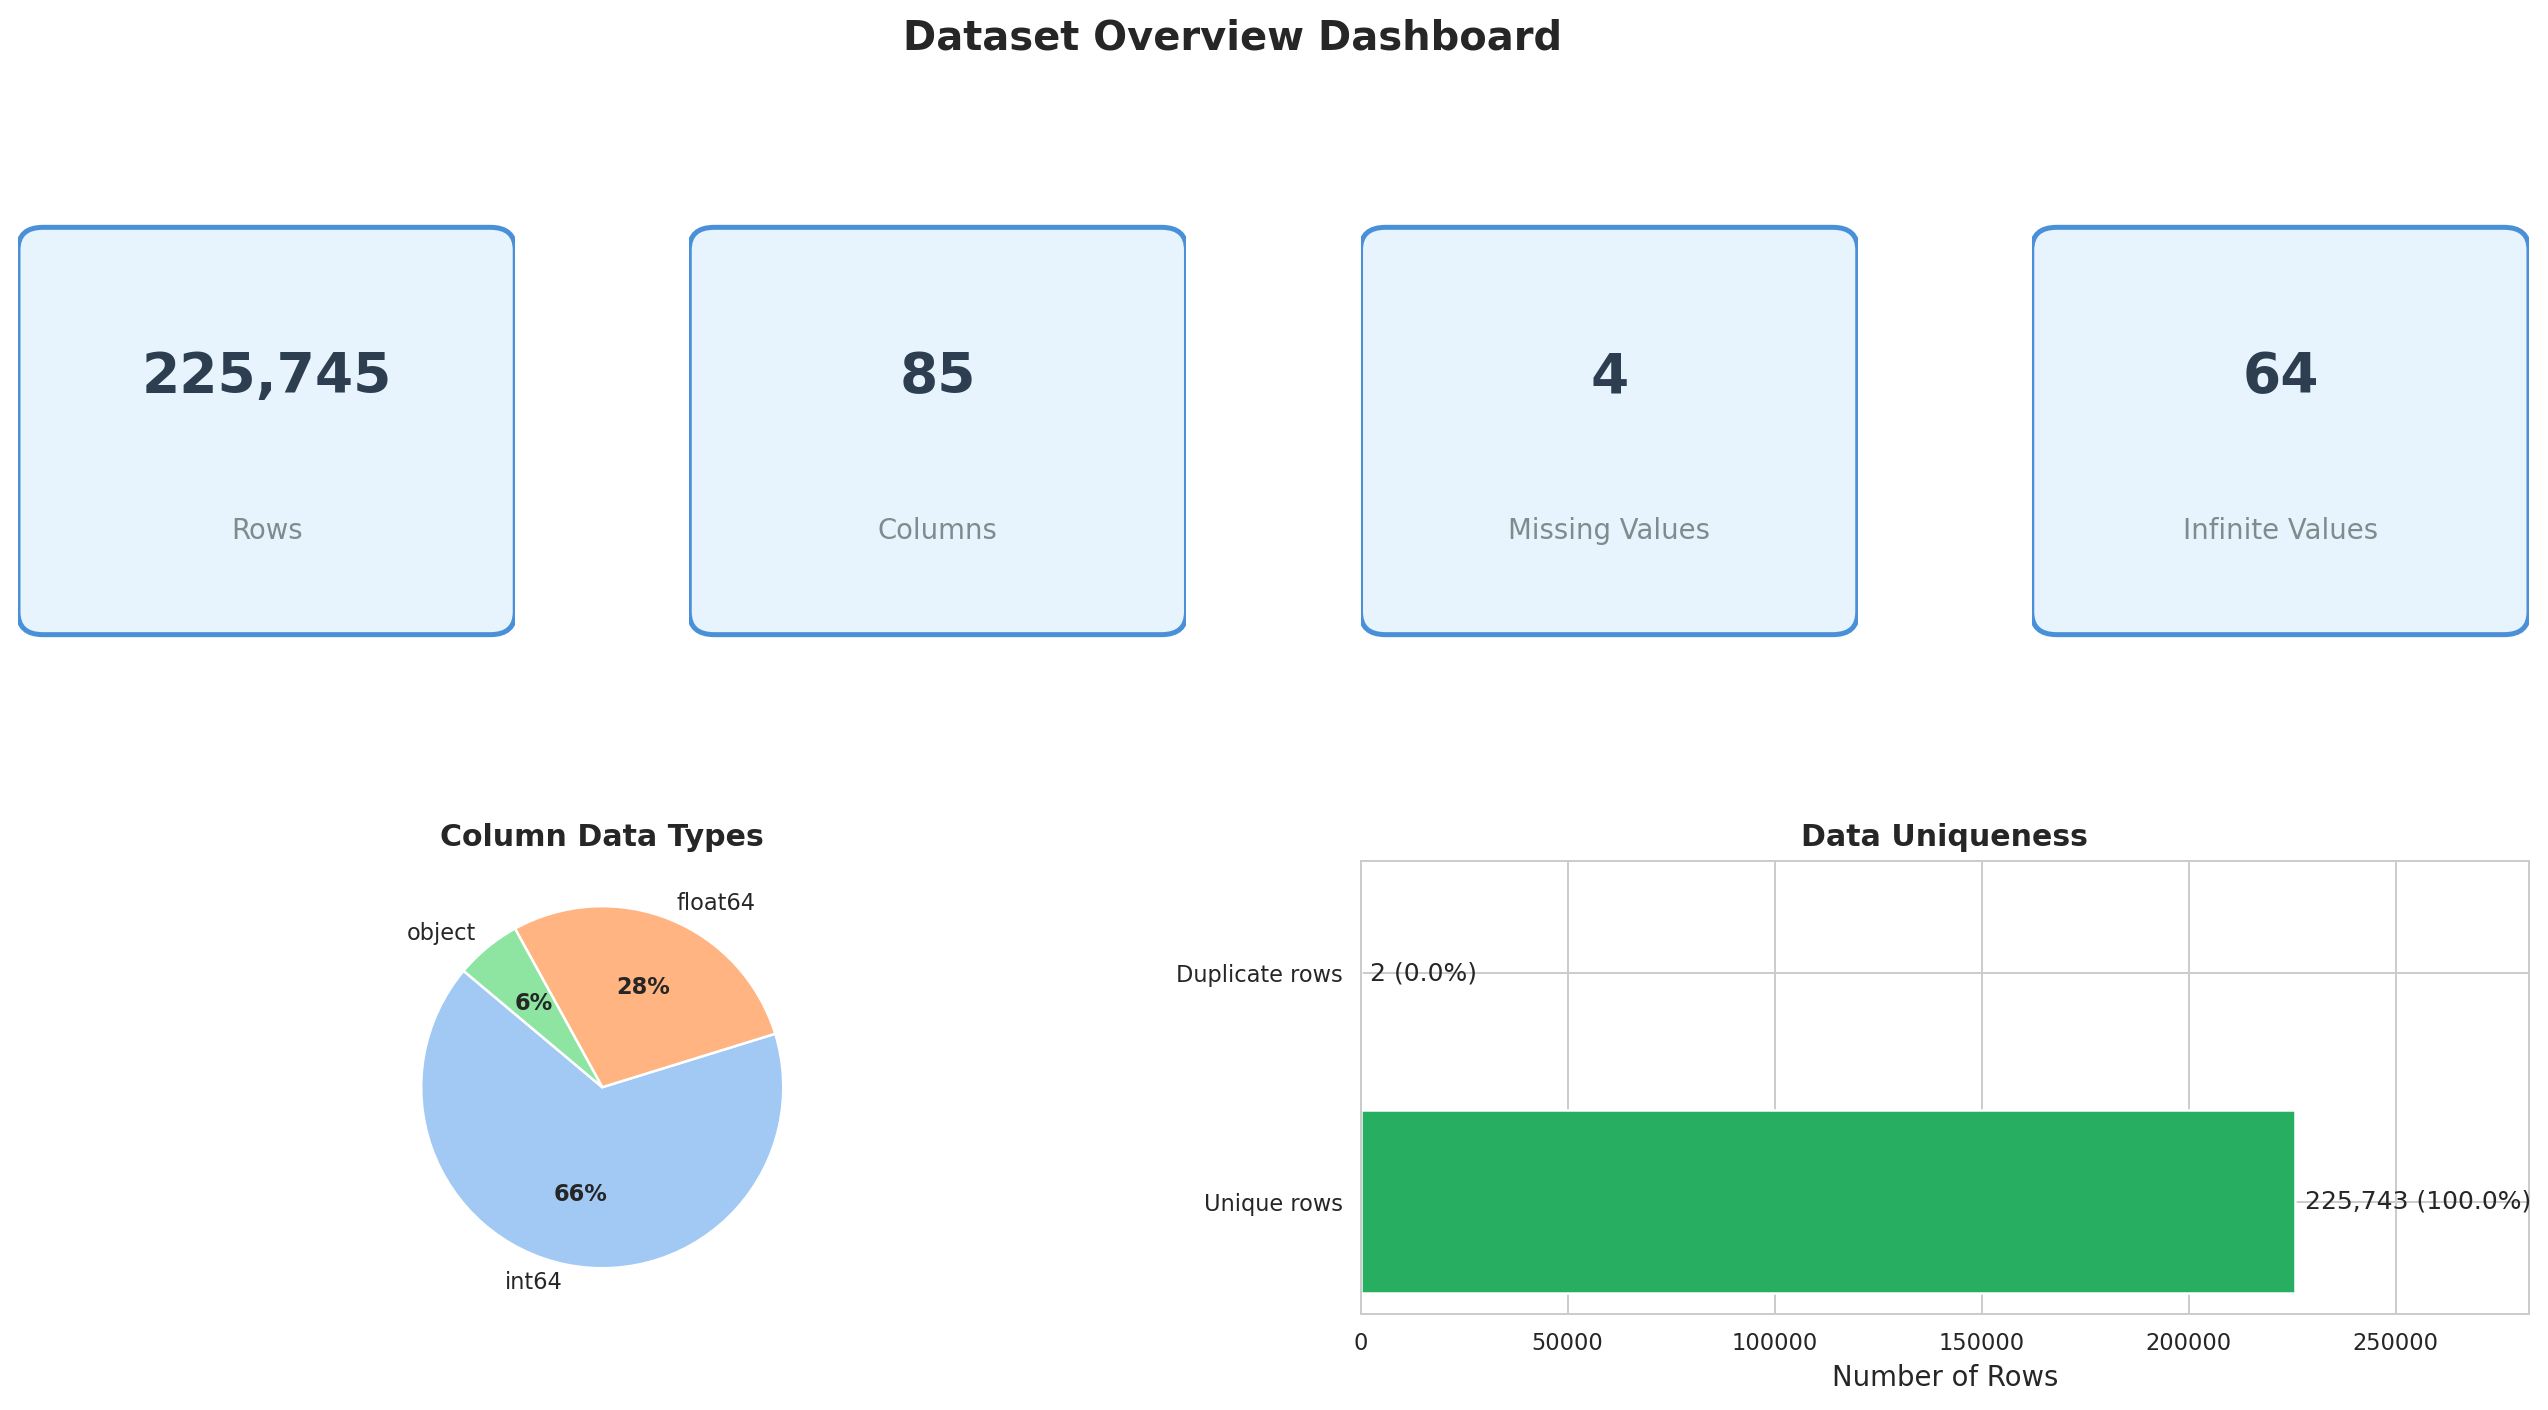


--- 02 Class Distribution ---


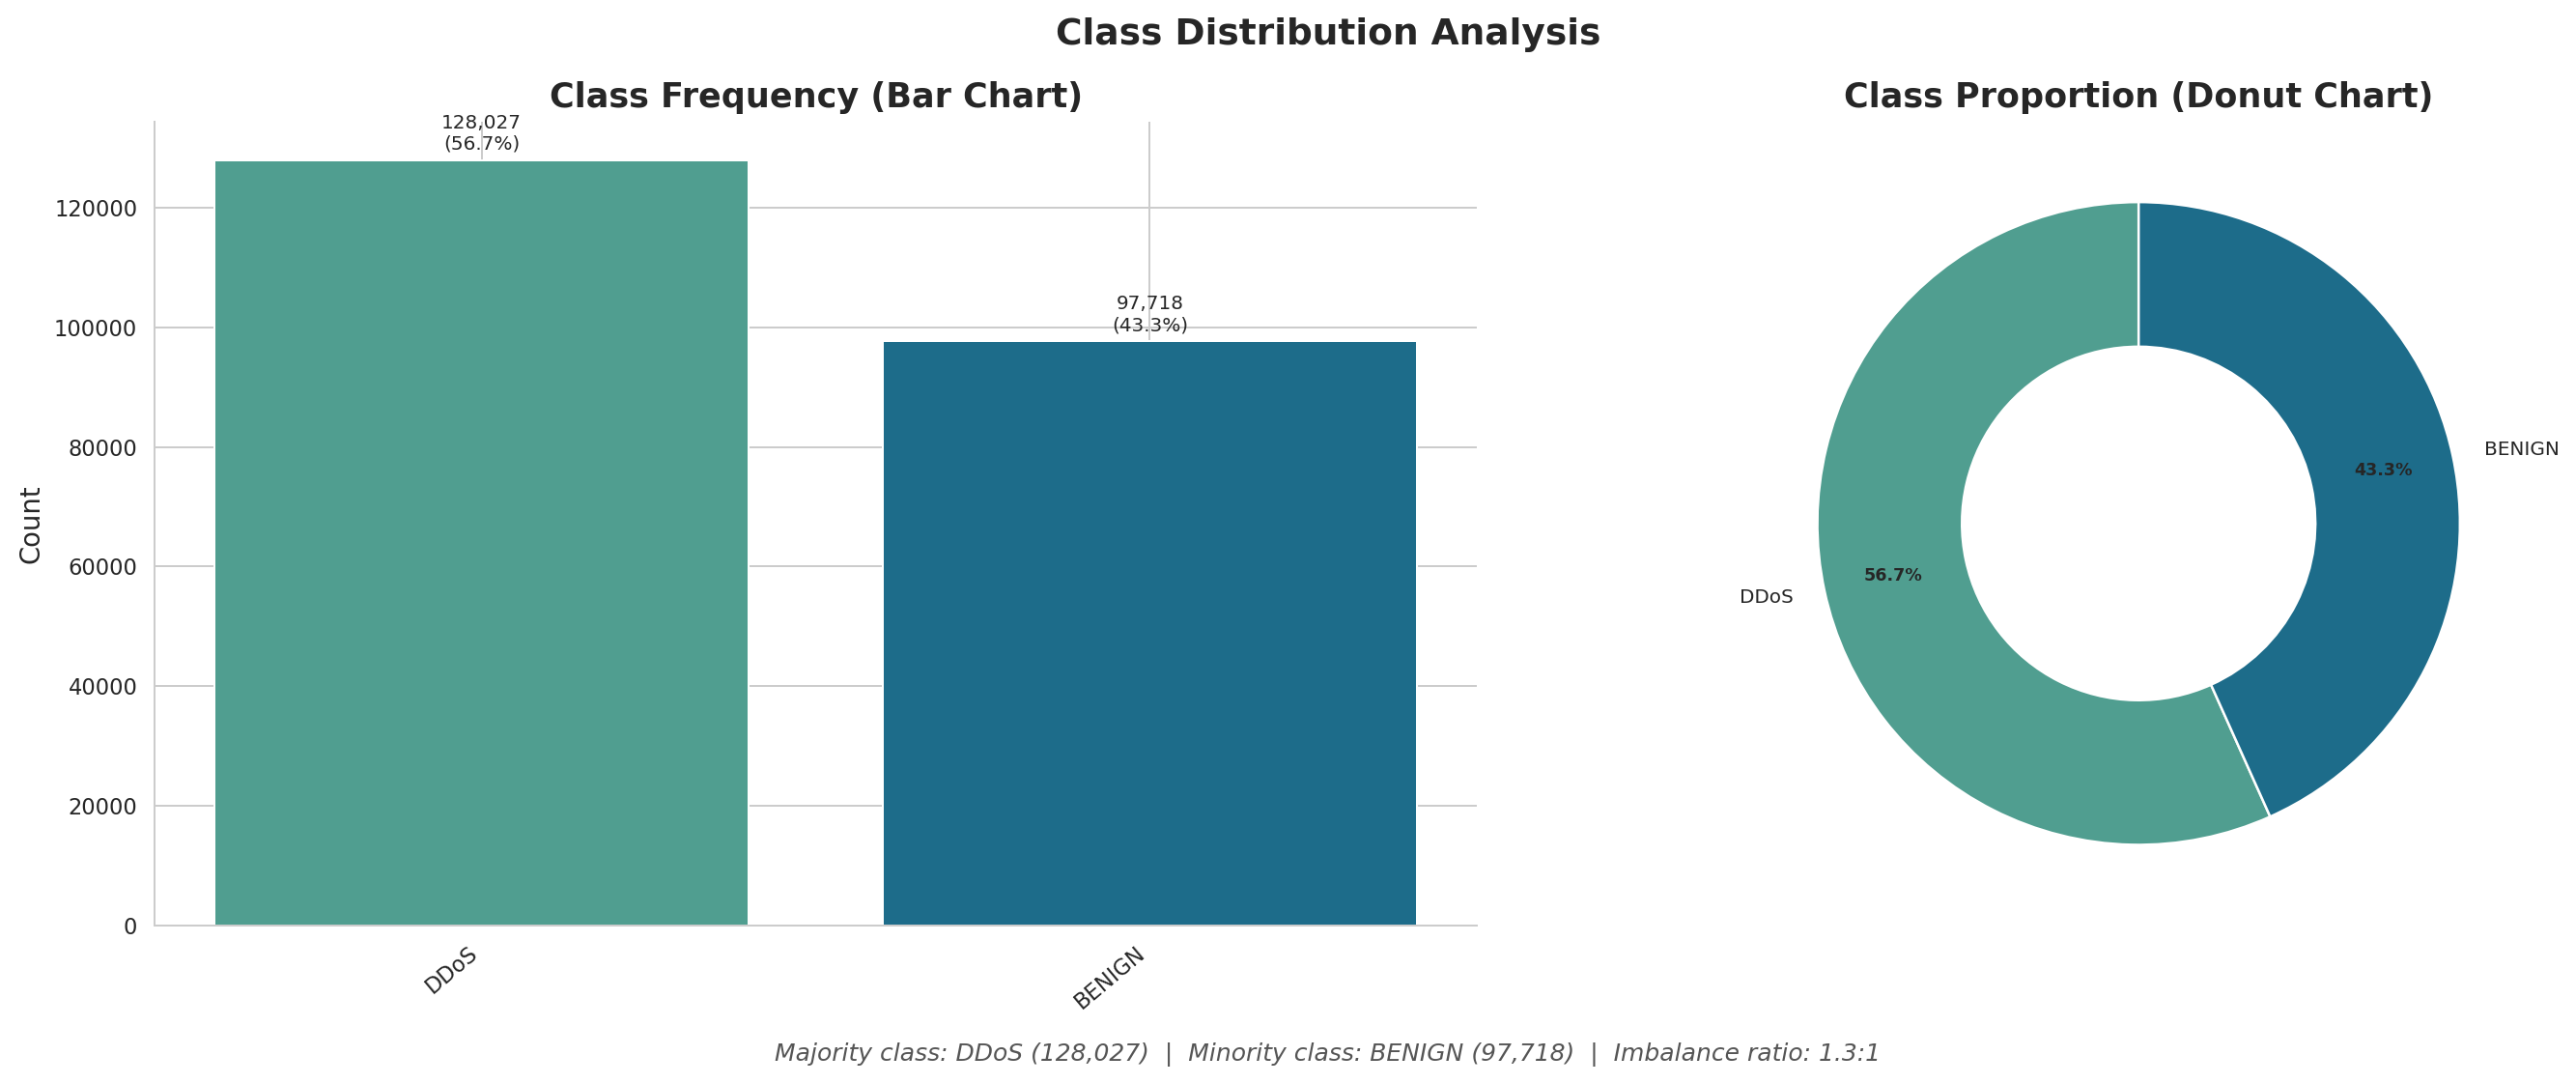


--- 03 Data Quality Matrix ---


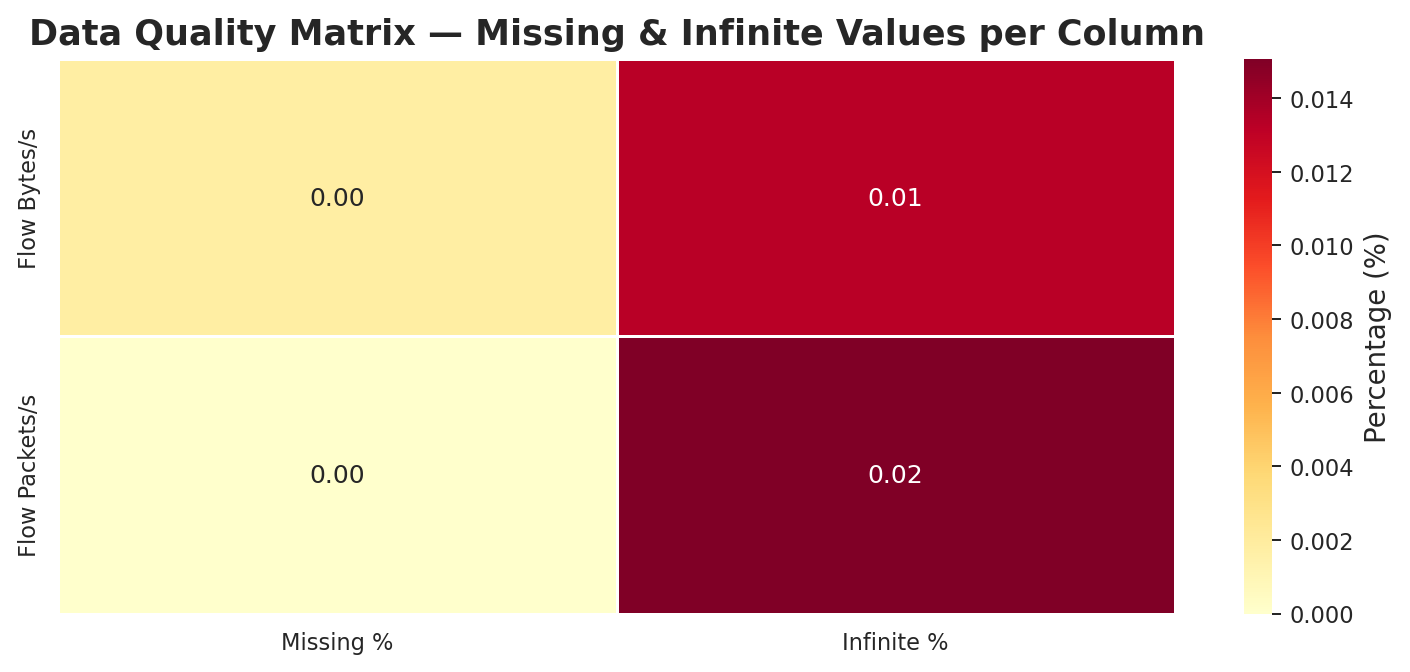


--- 04 Feature Statistics Table ---


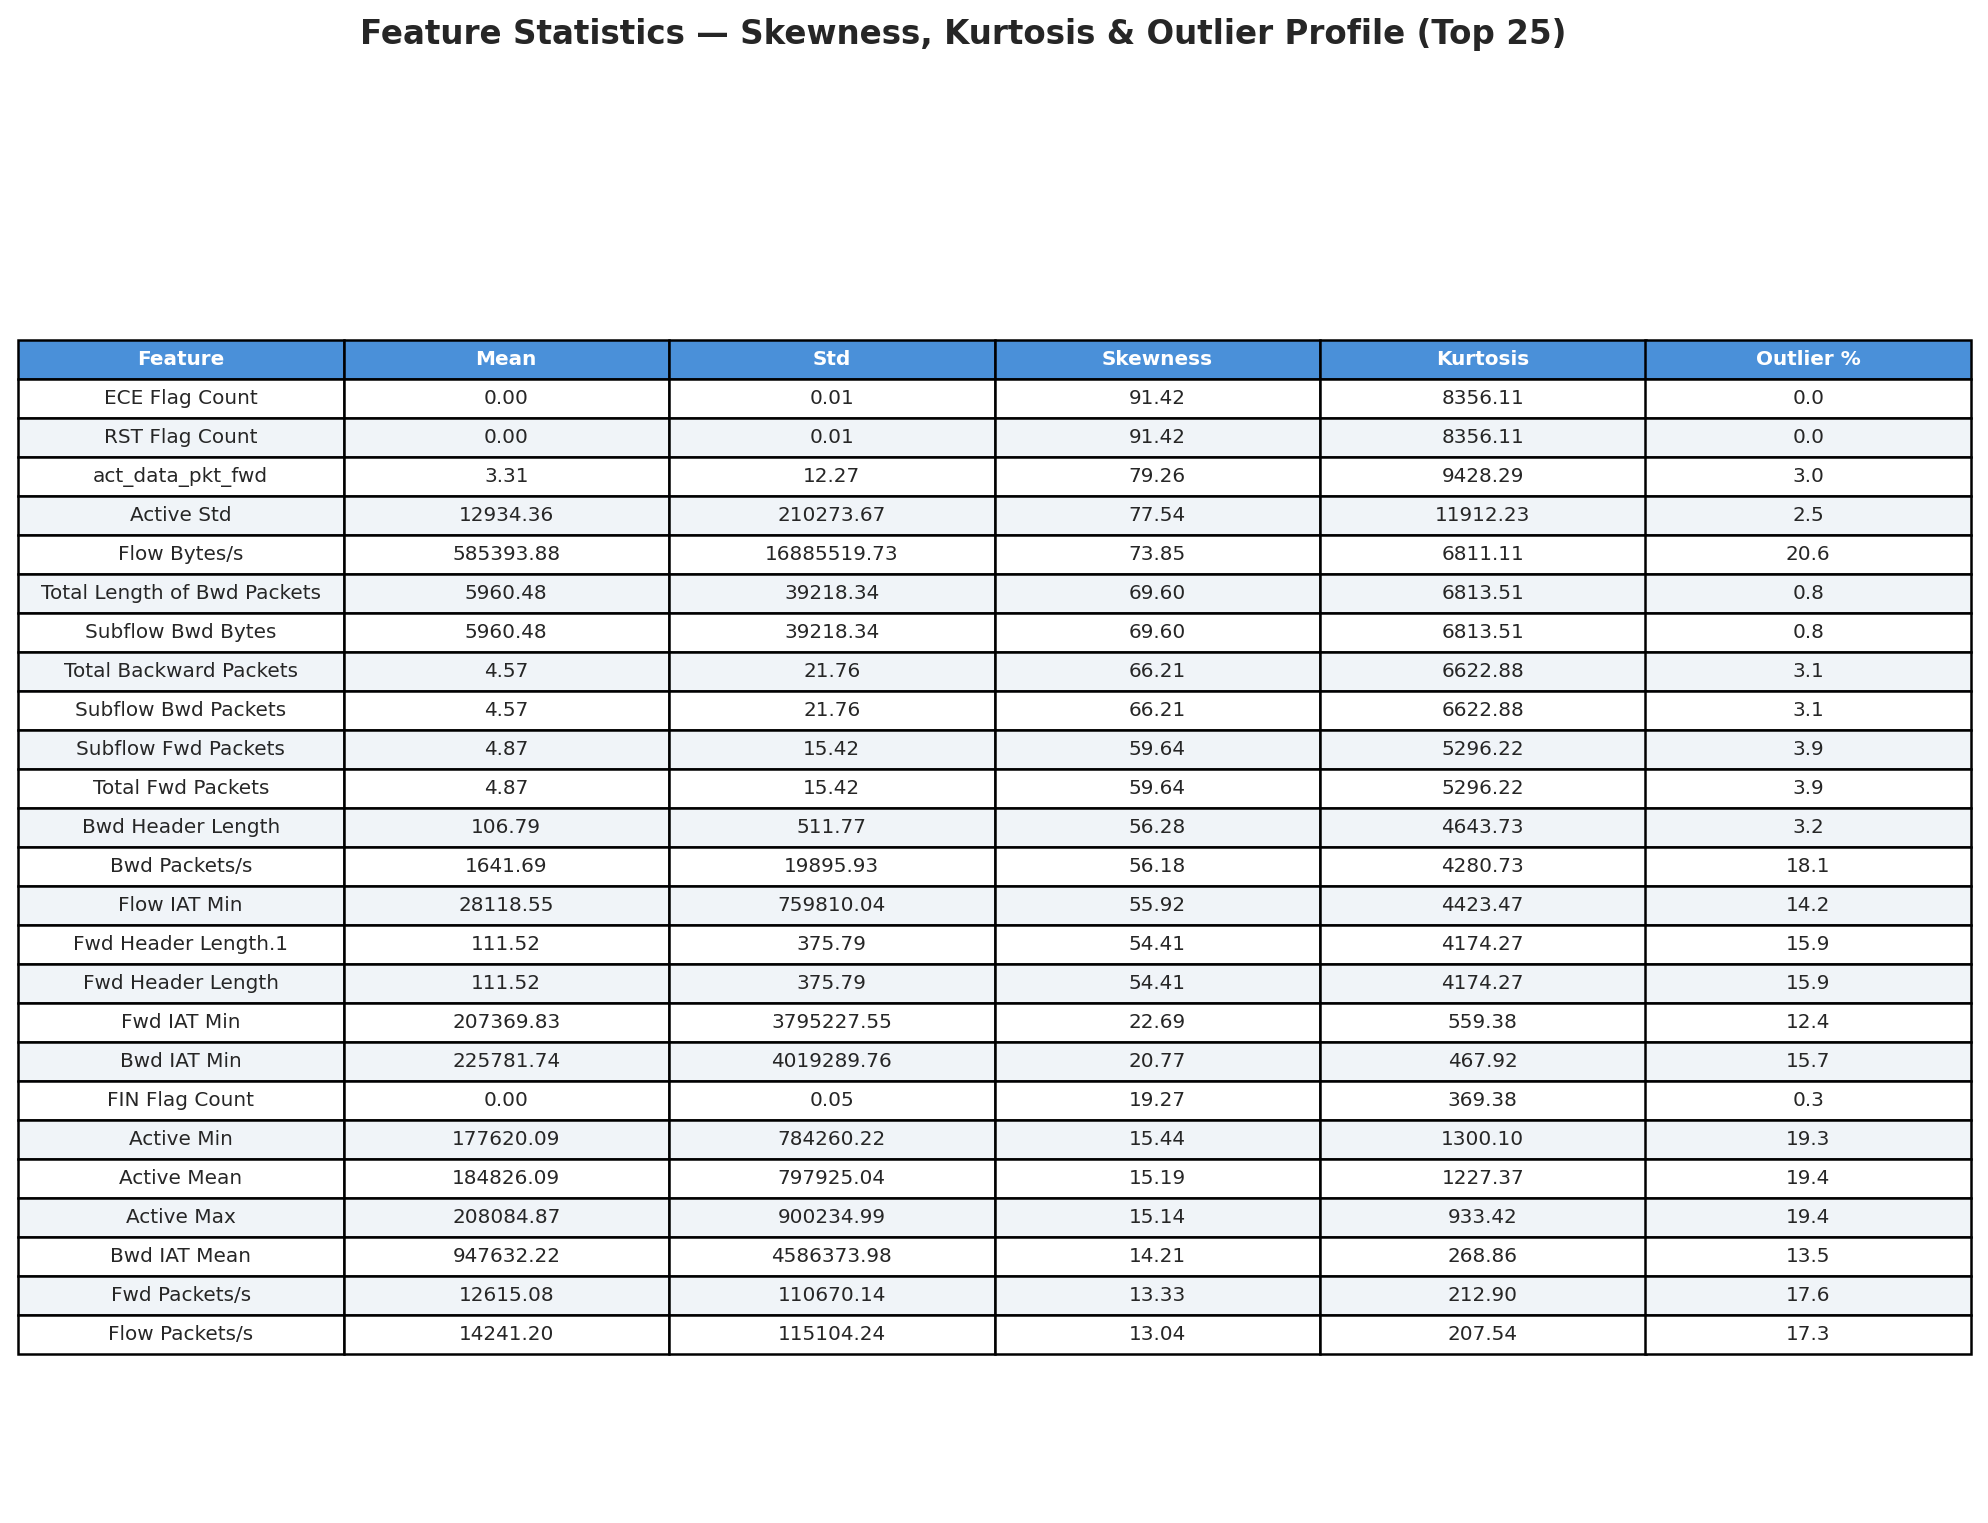


--- 05A Correlation Clustered Heatmap ---


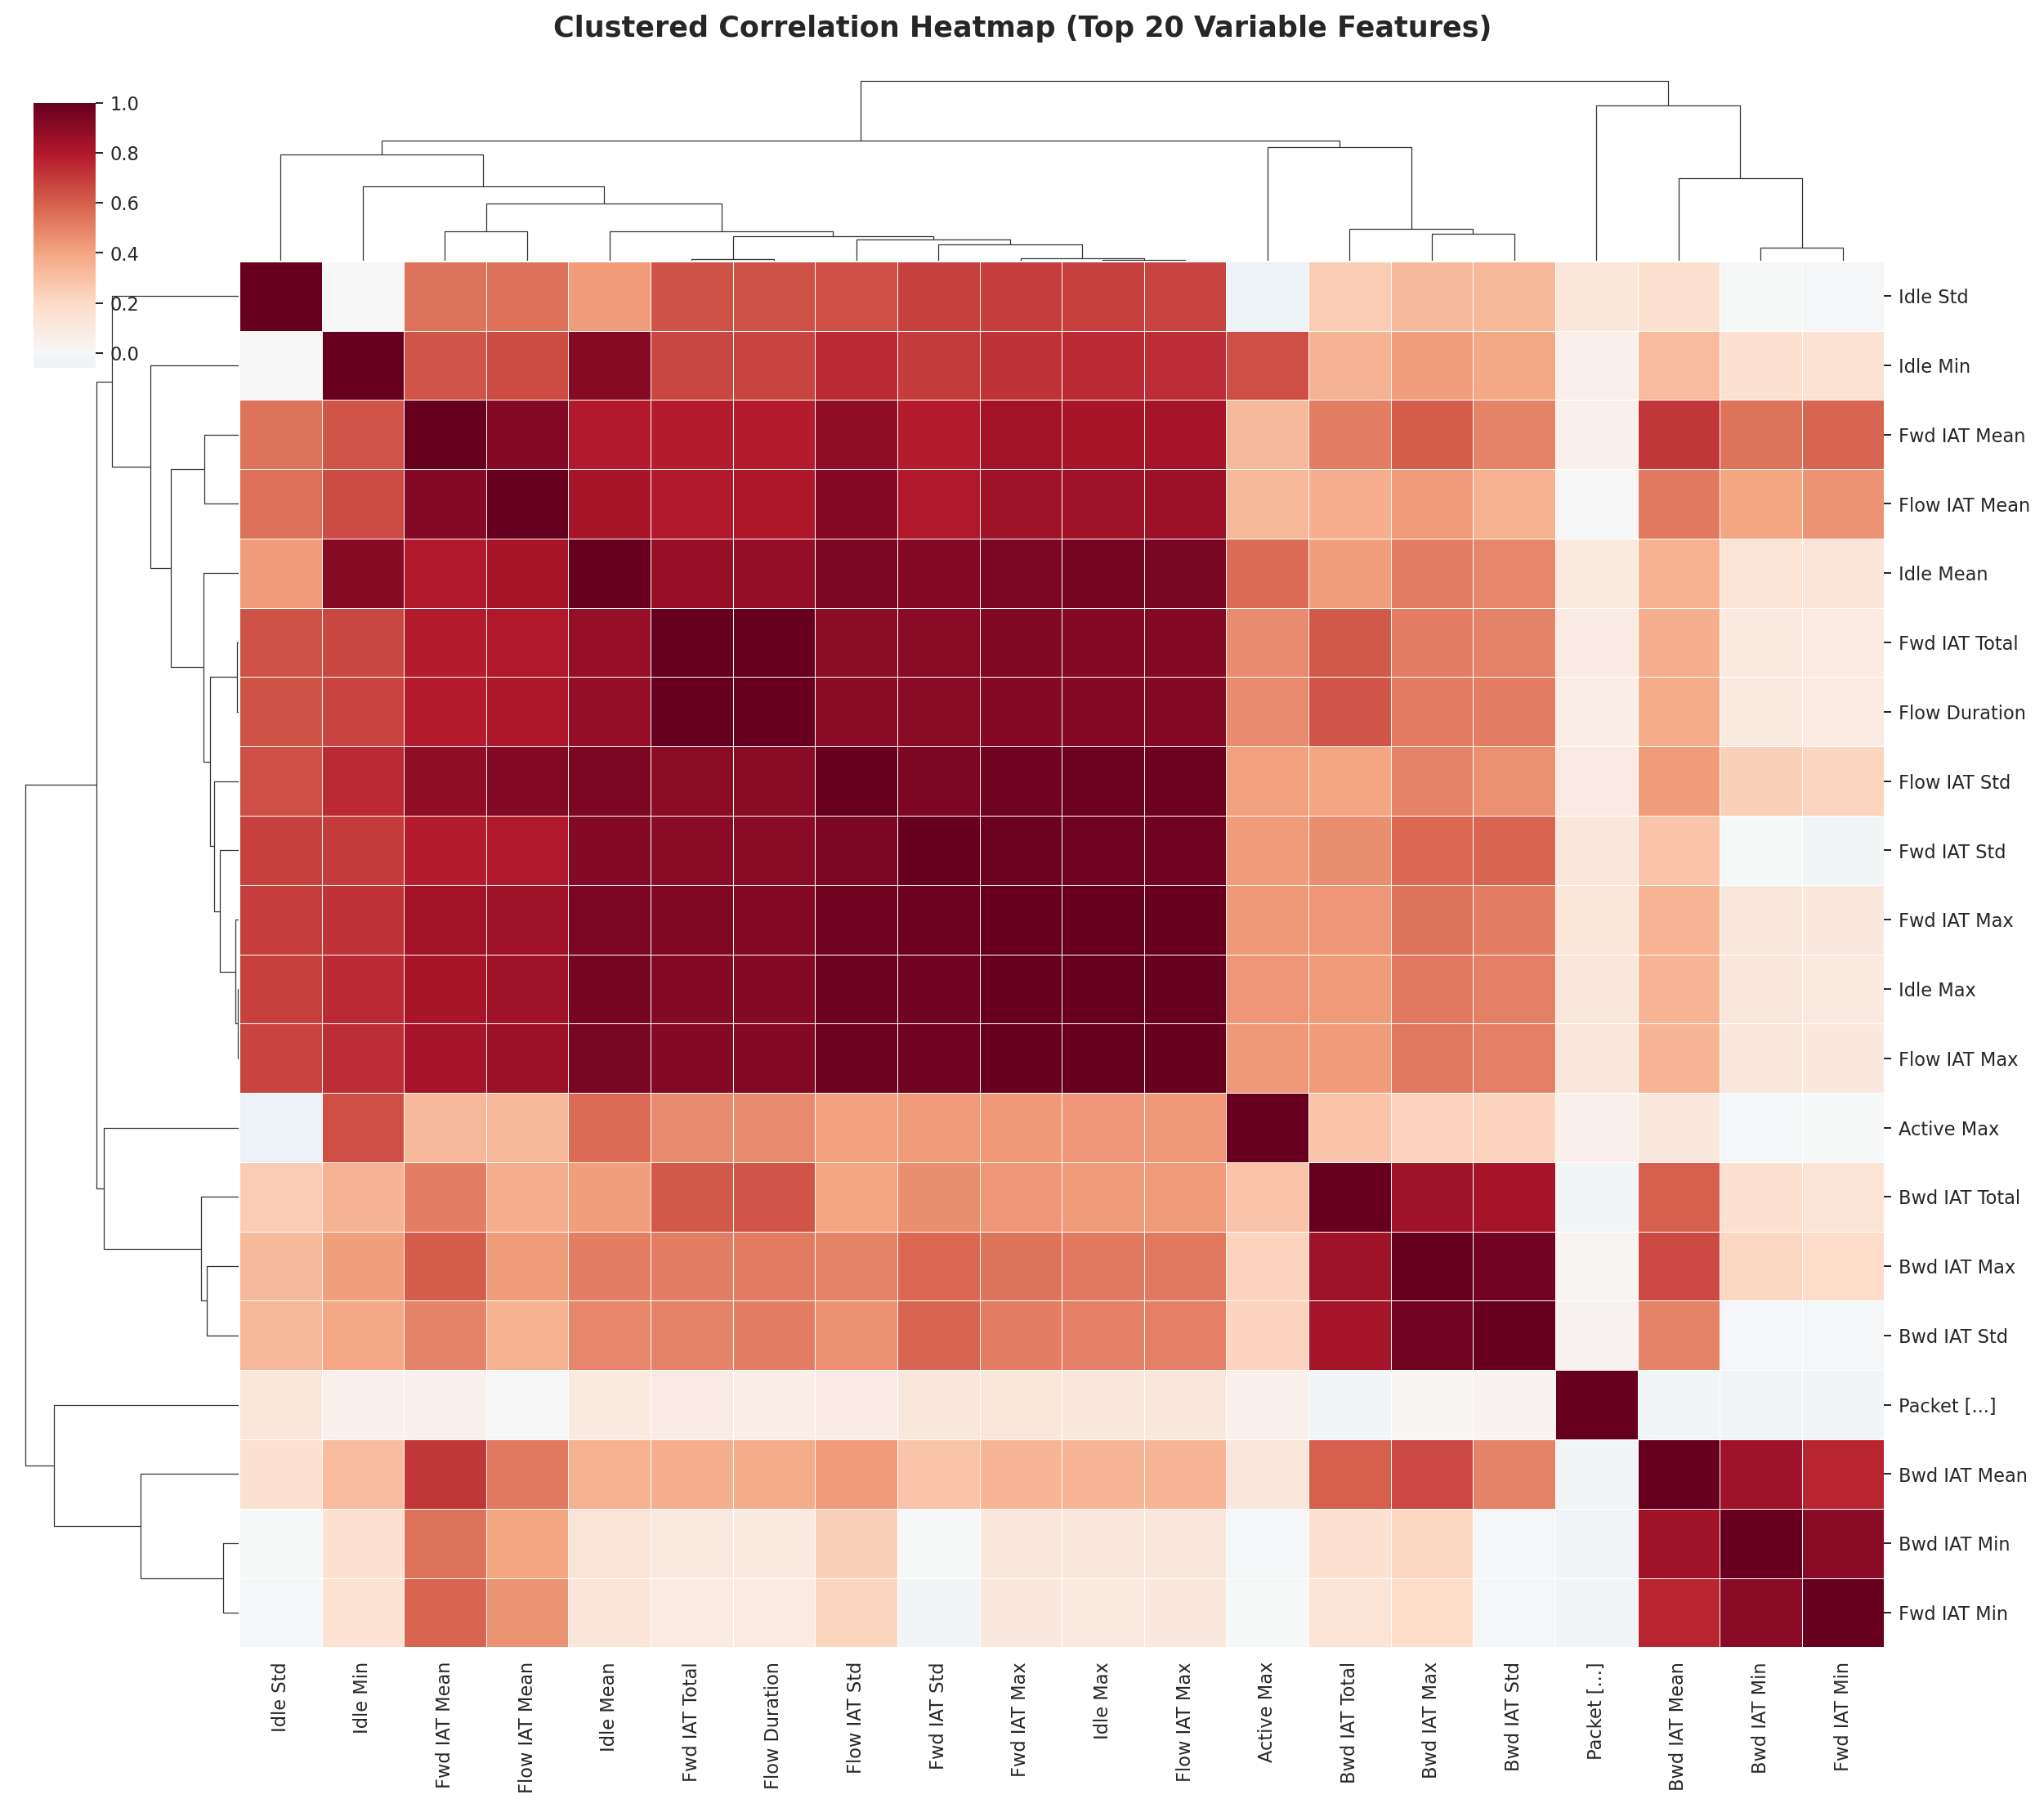


--- 05B Top Correlated Pairs ---


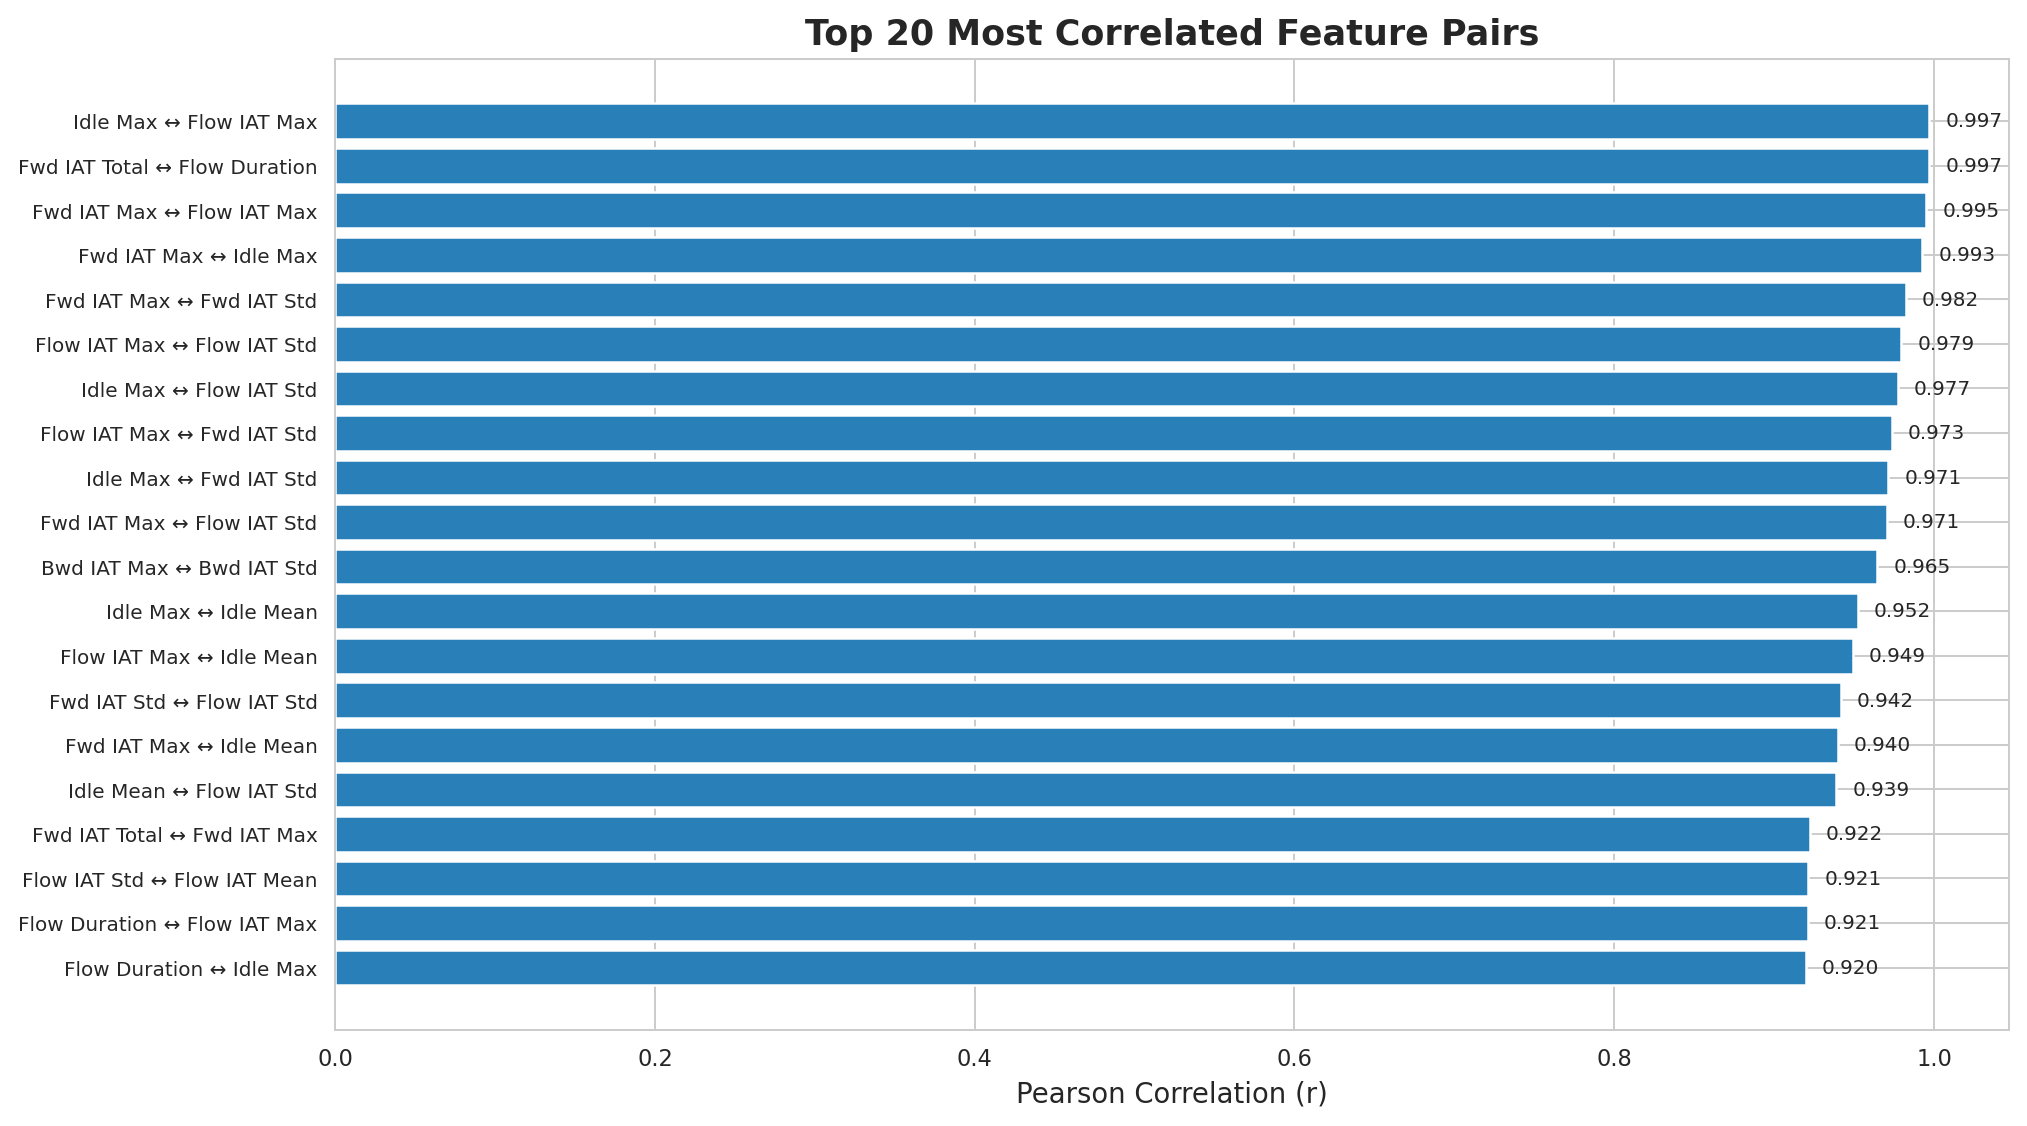


--- 06 Feature Distributions Violin ---


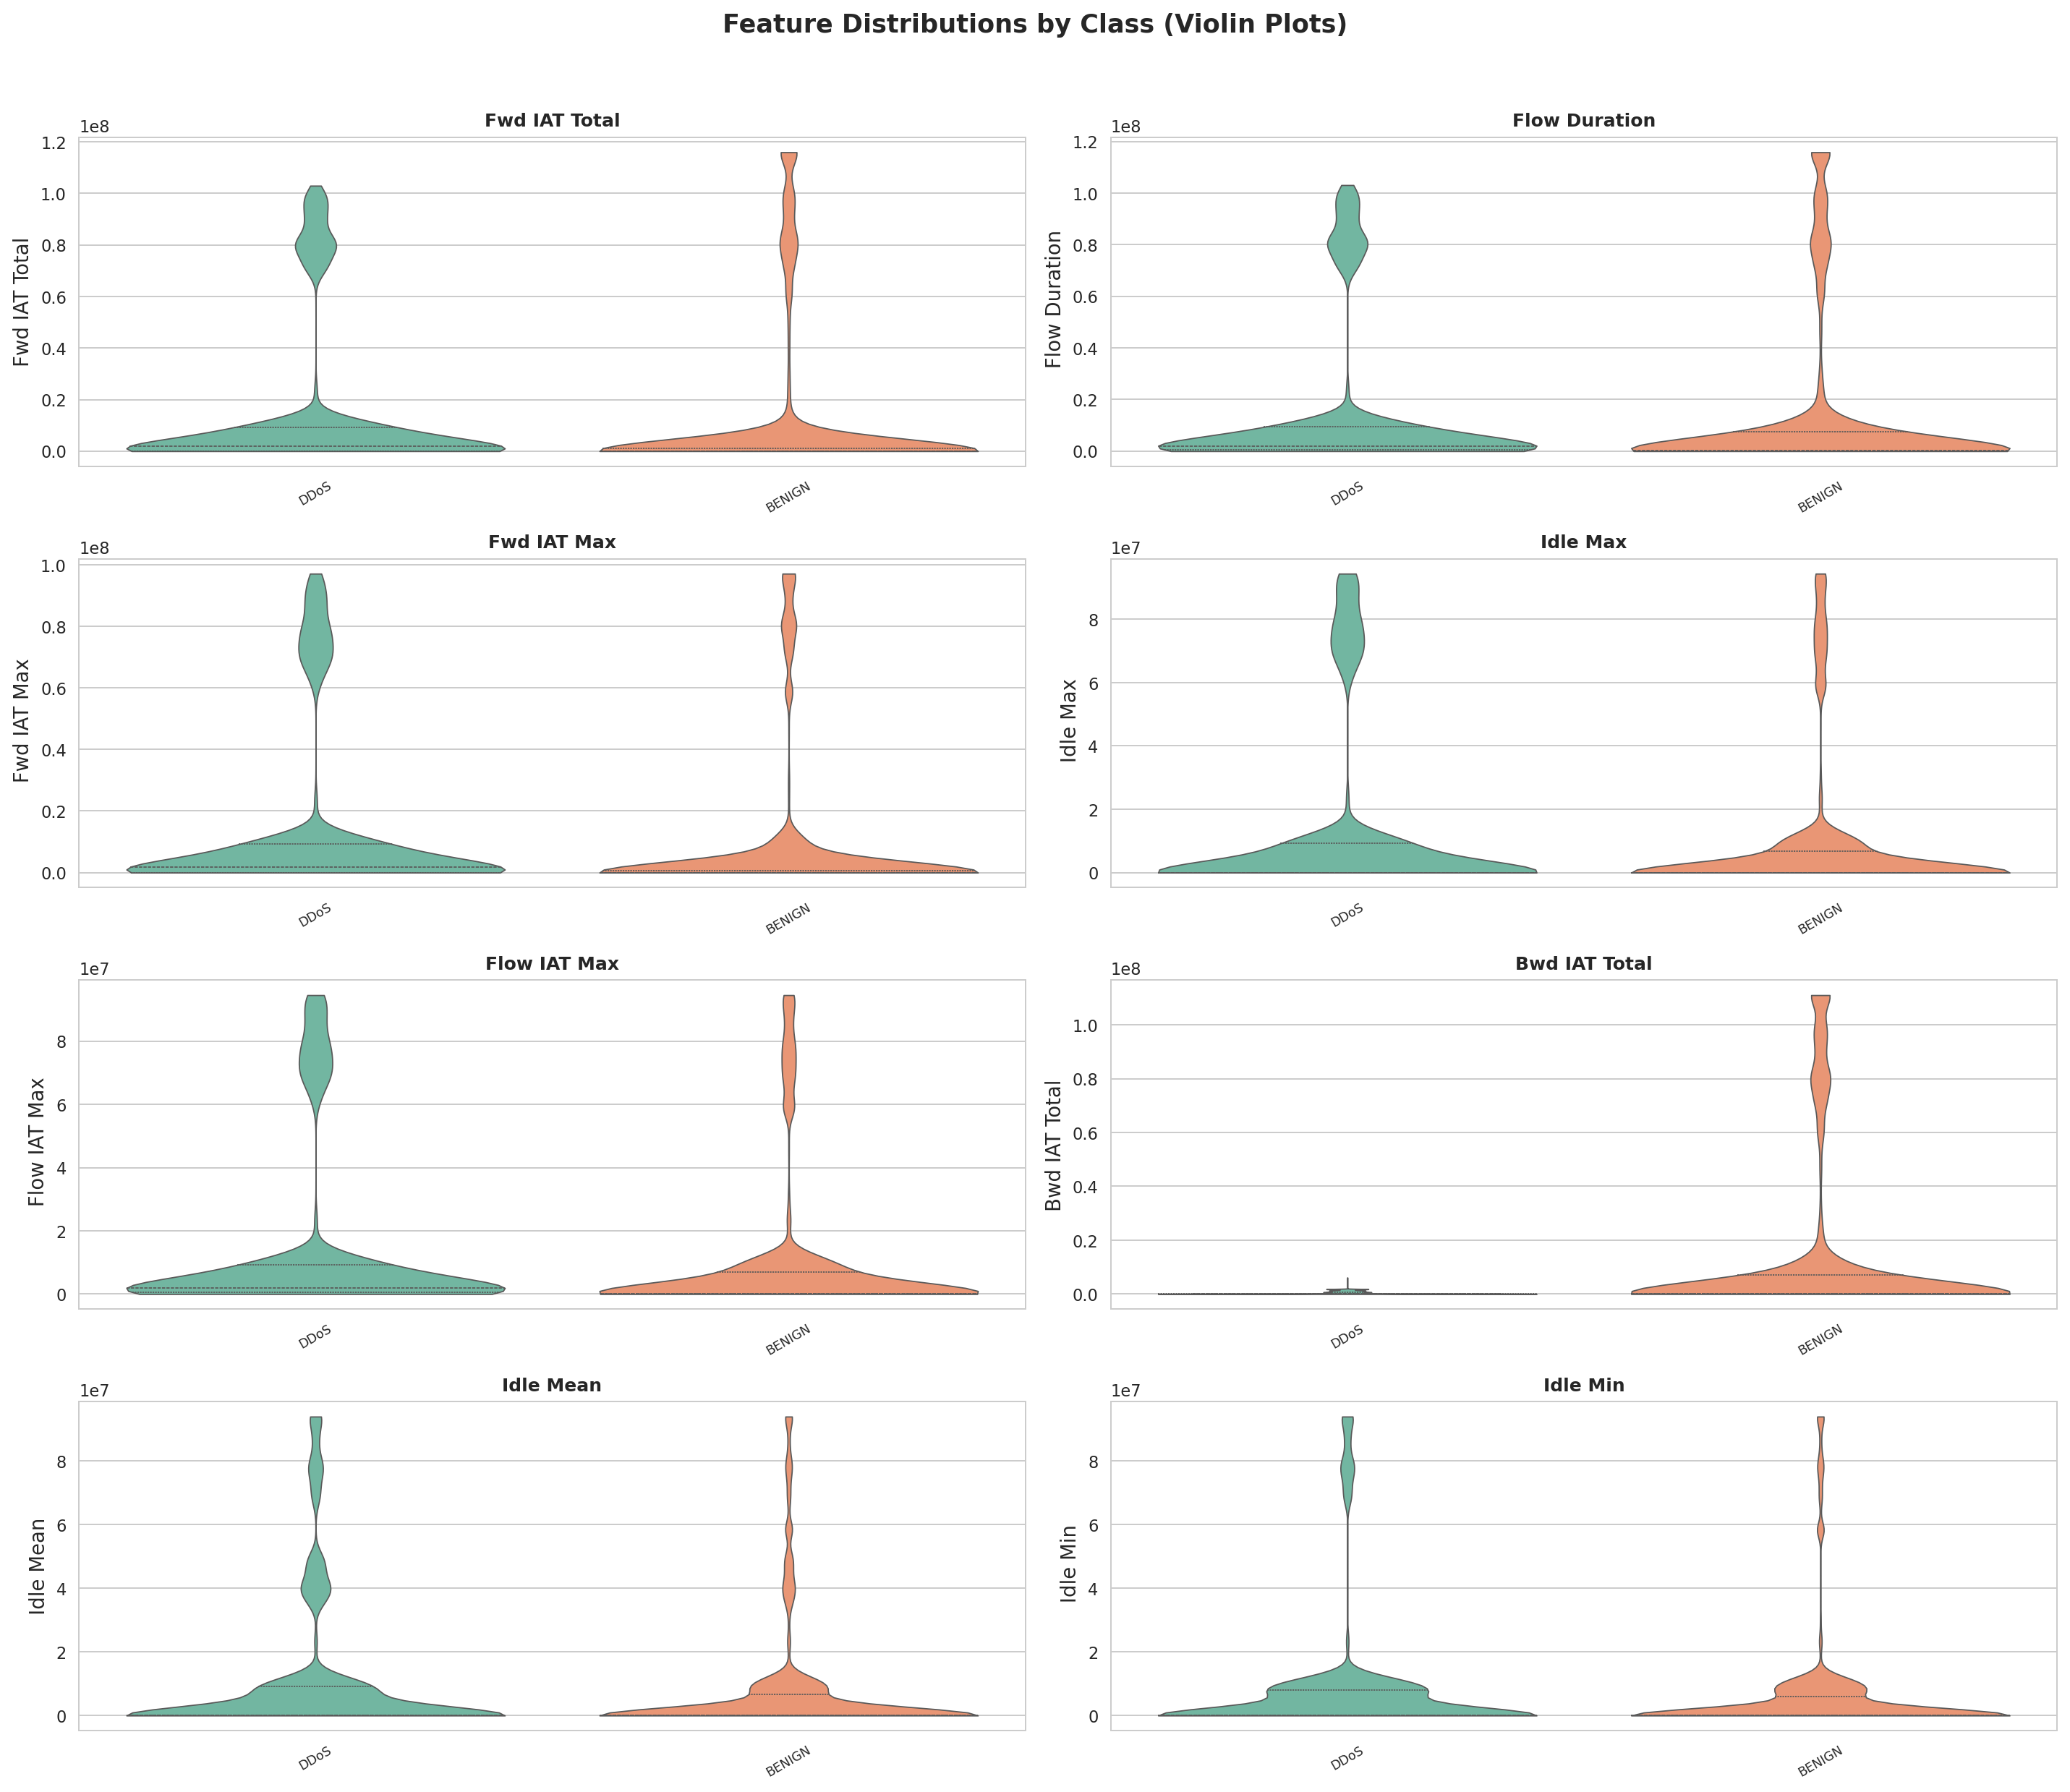


--- 07 Kde Histograms ---


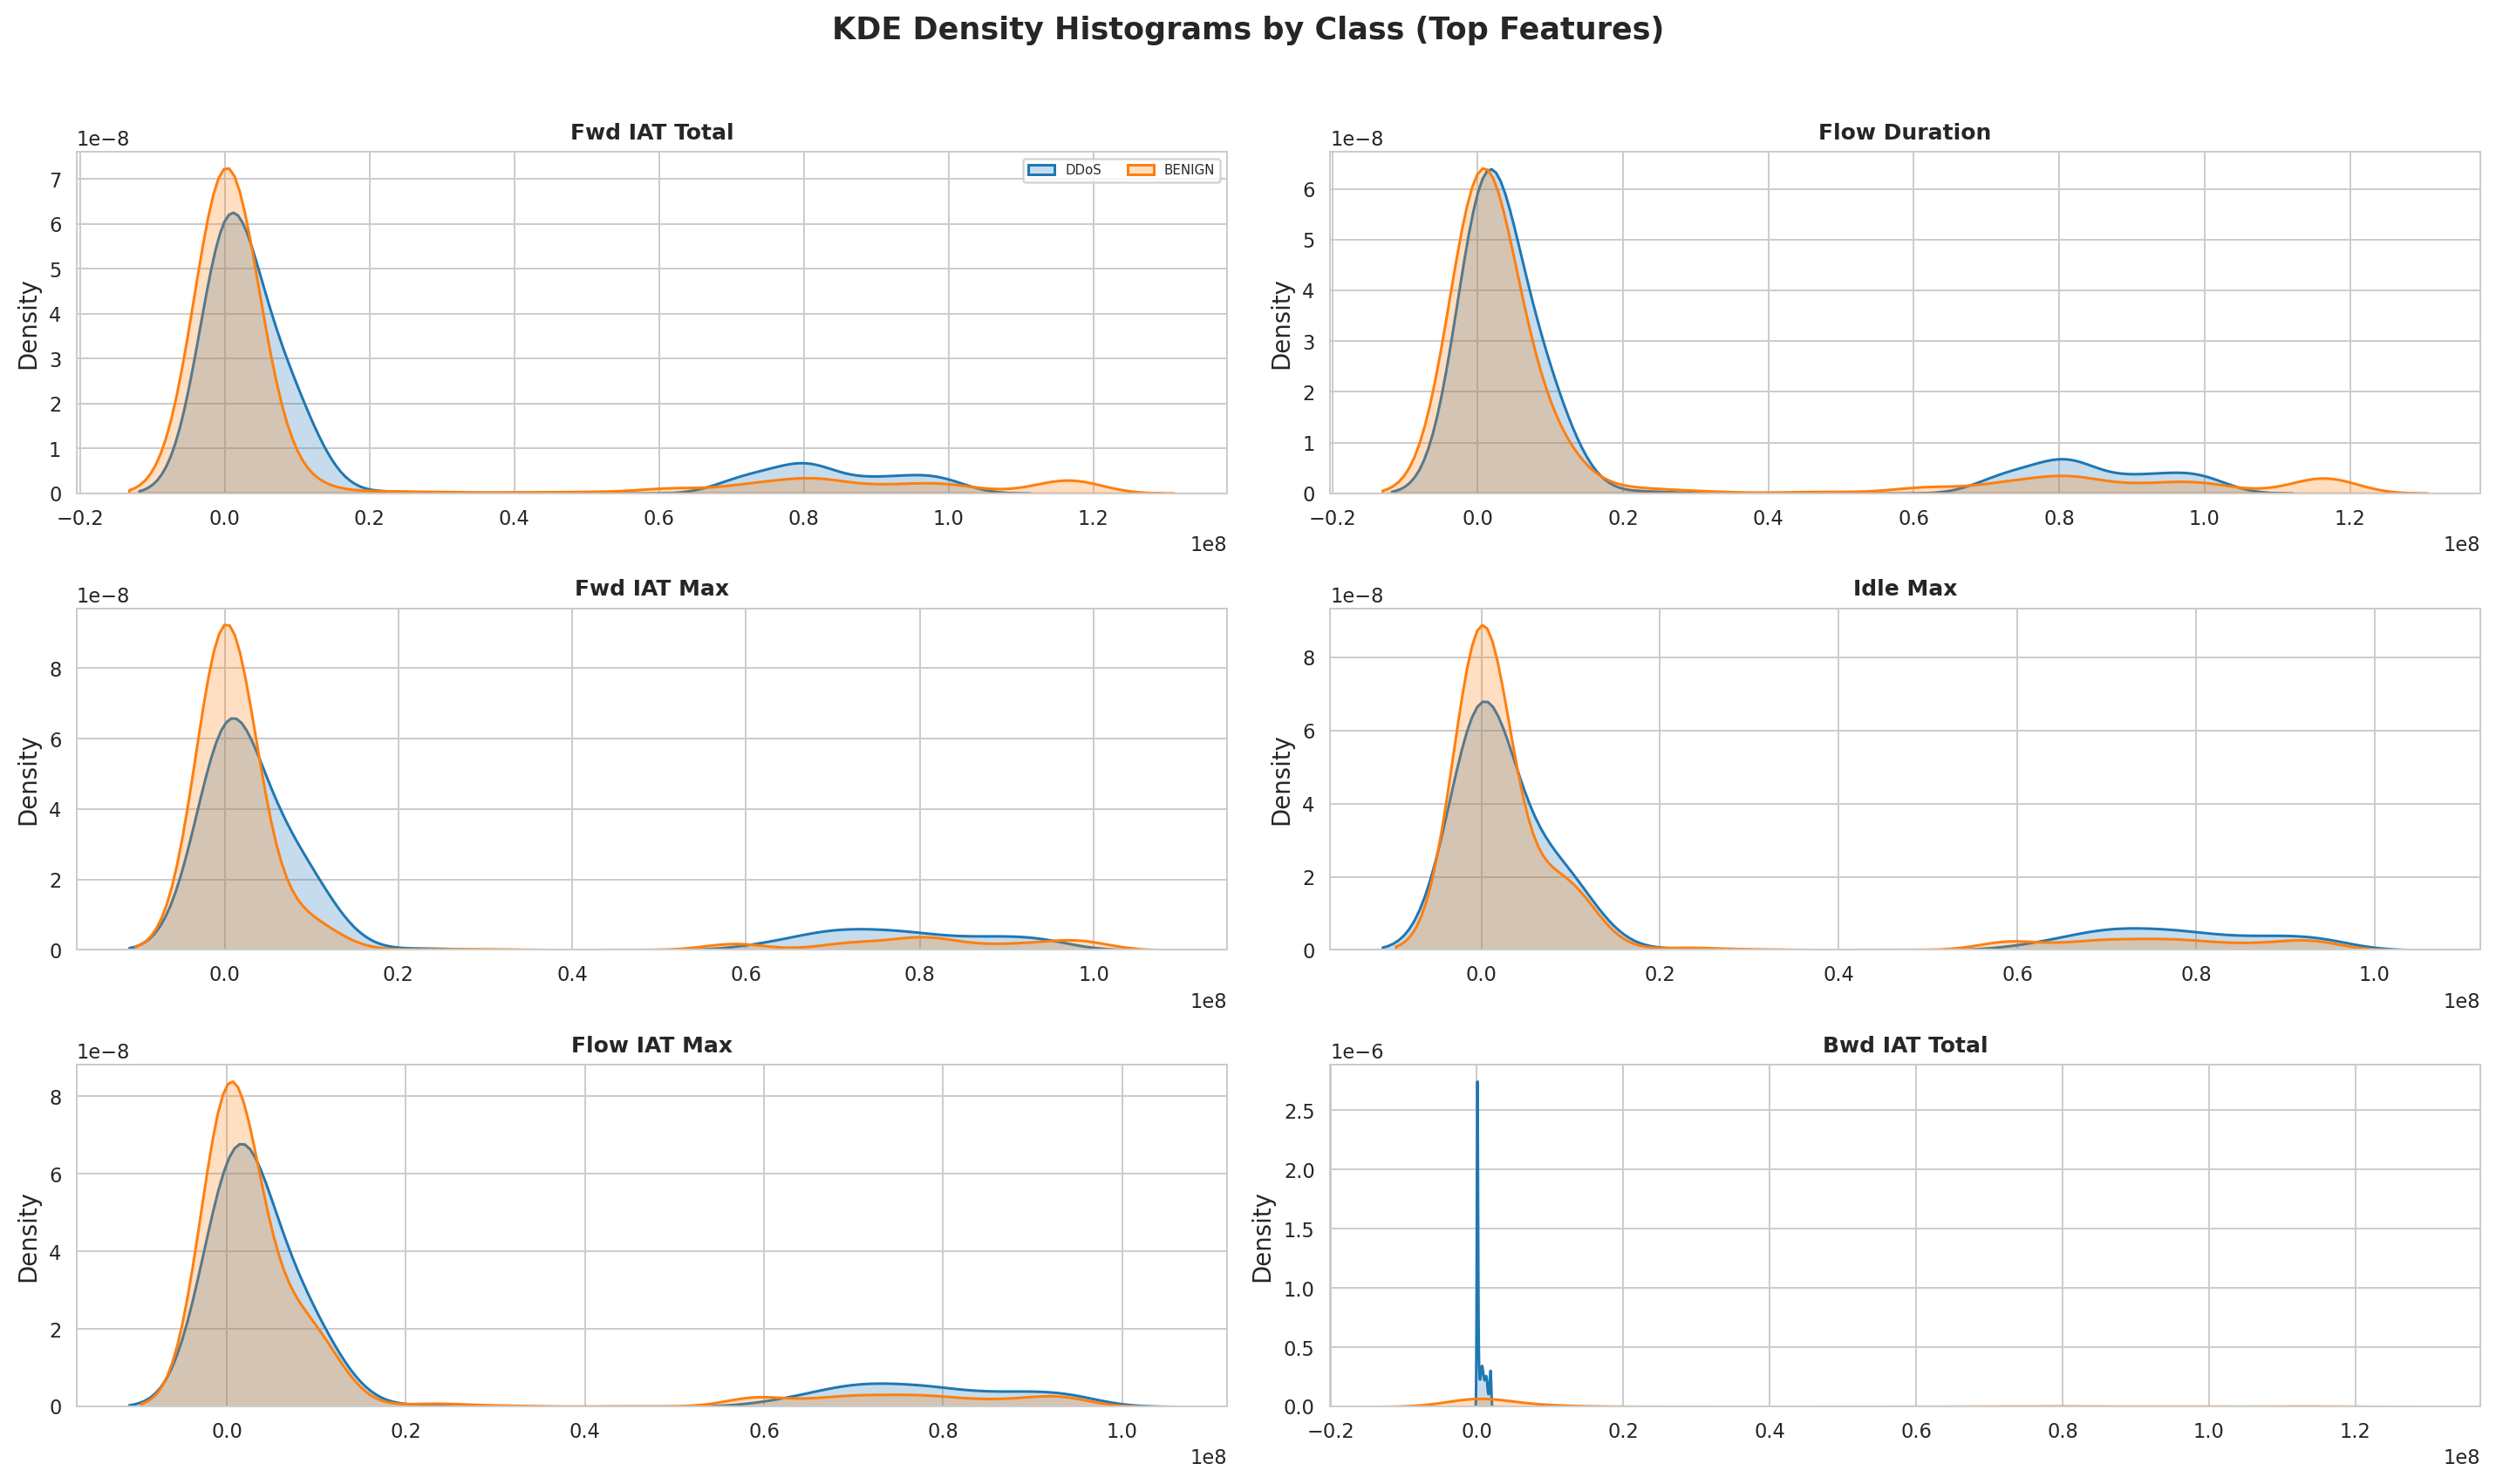


--- 08 Outlier Landscape ---


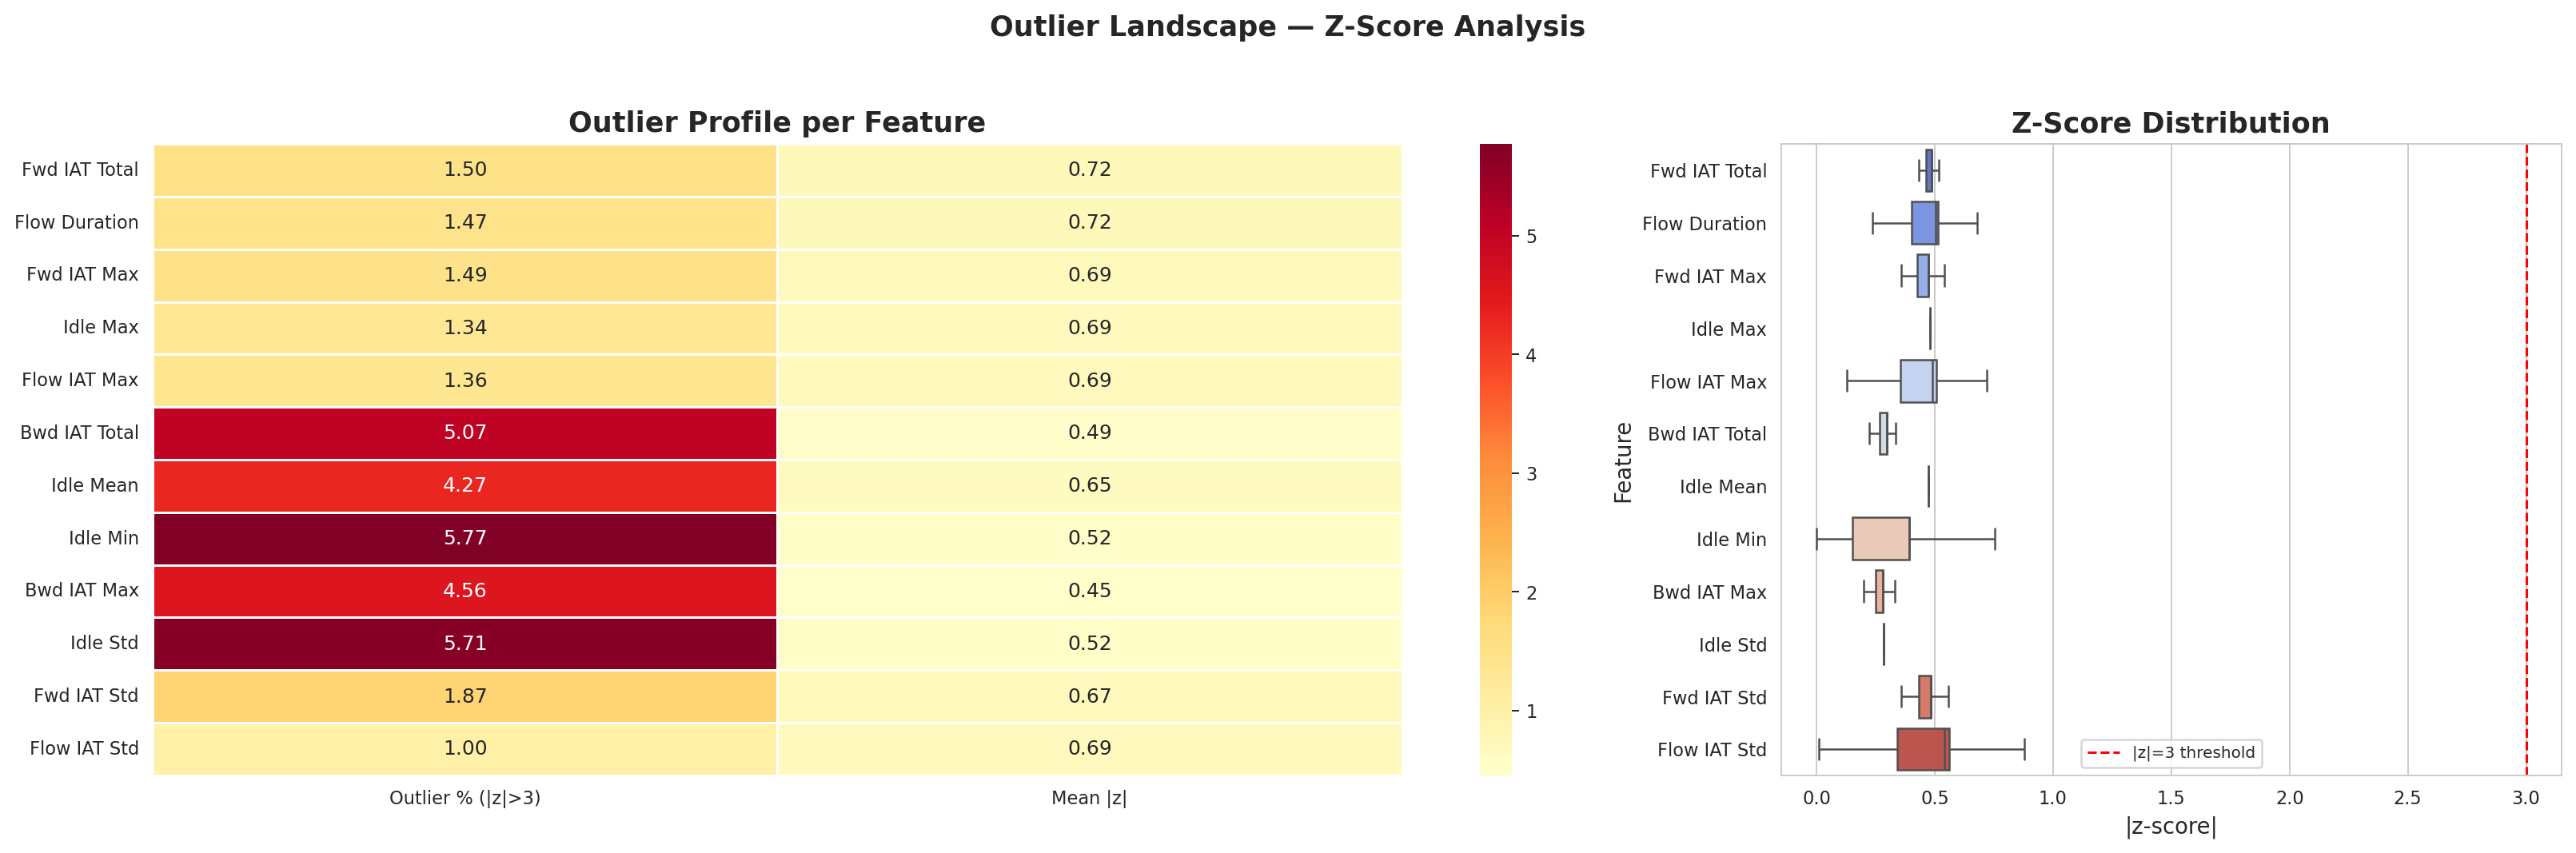


--- 09 Feature Variance Ranking ---


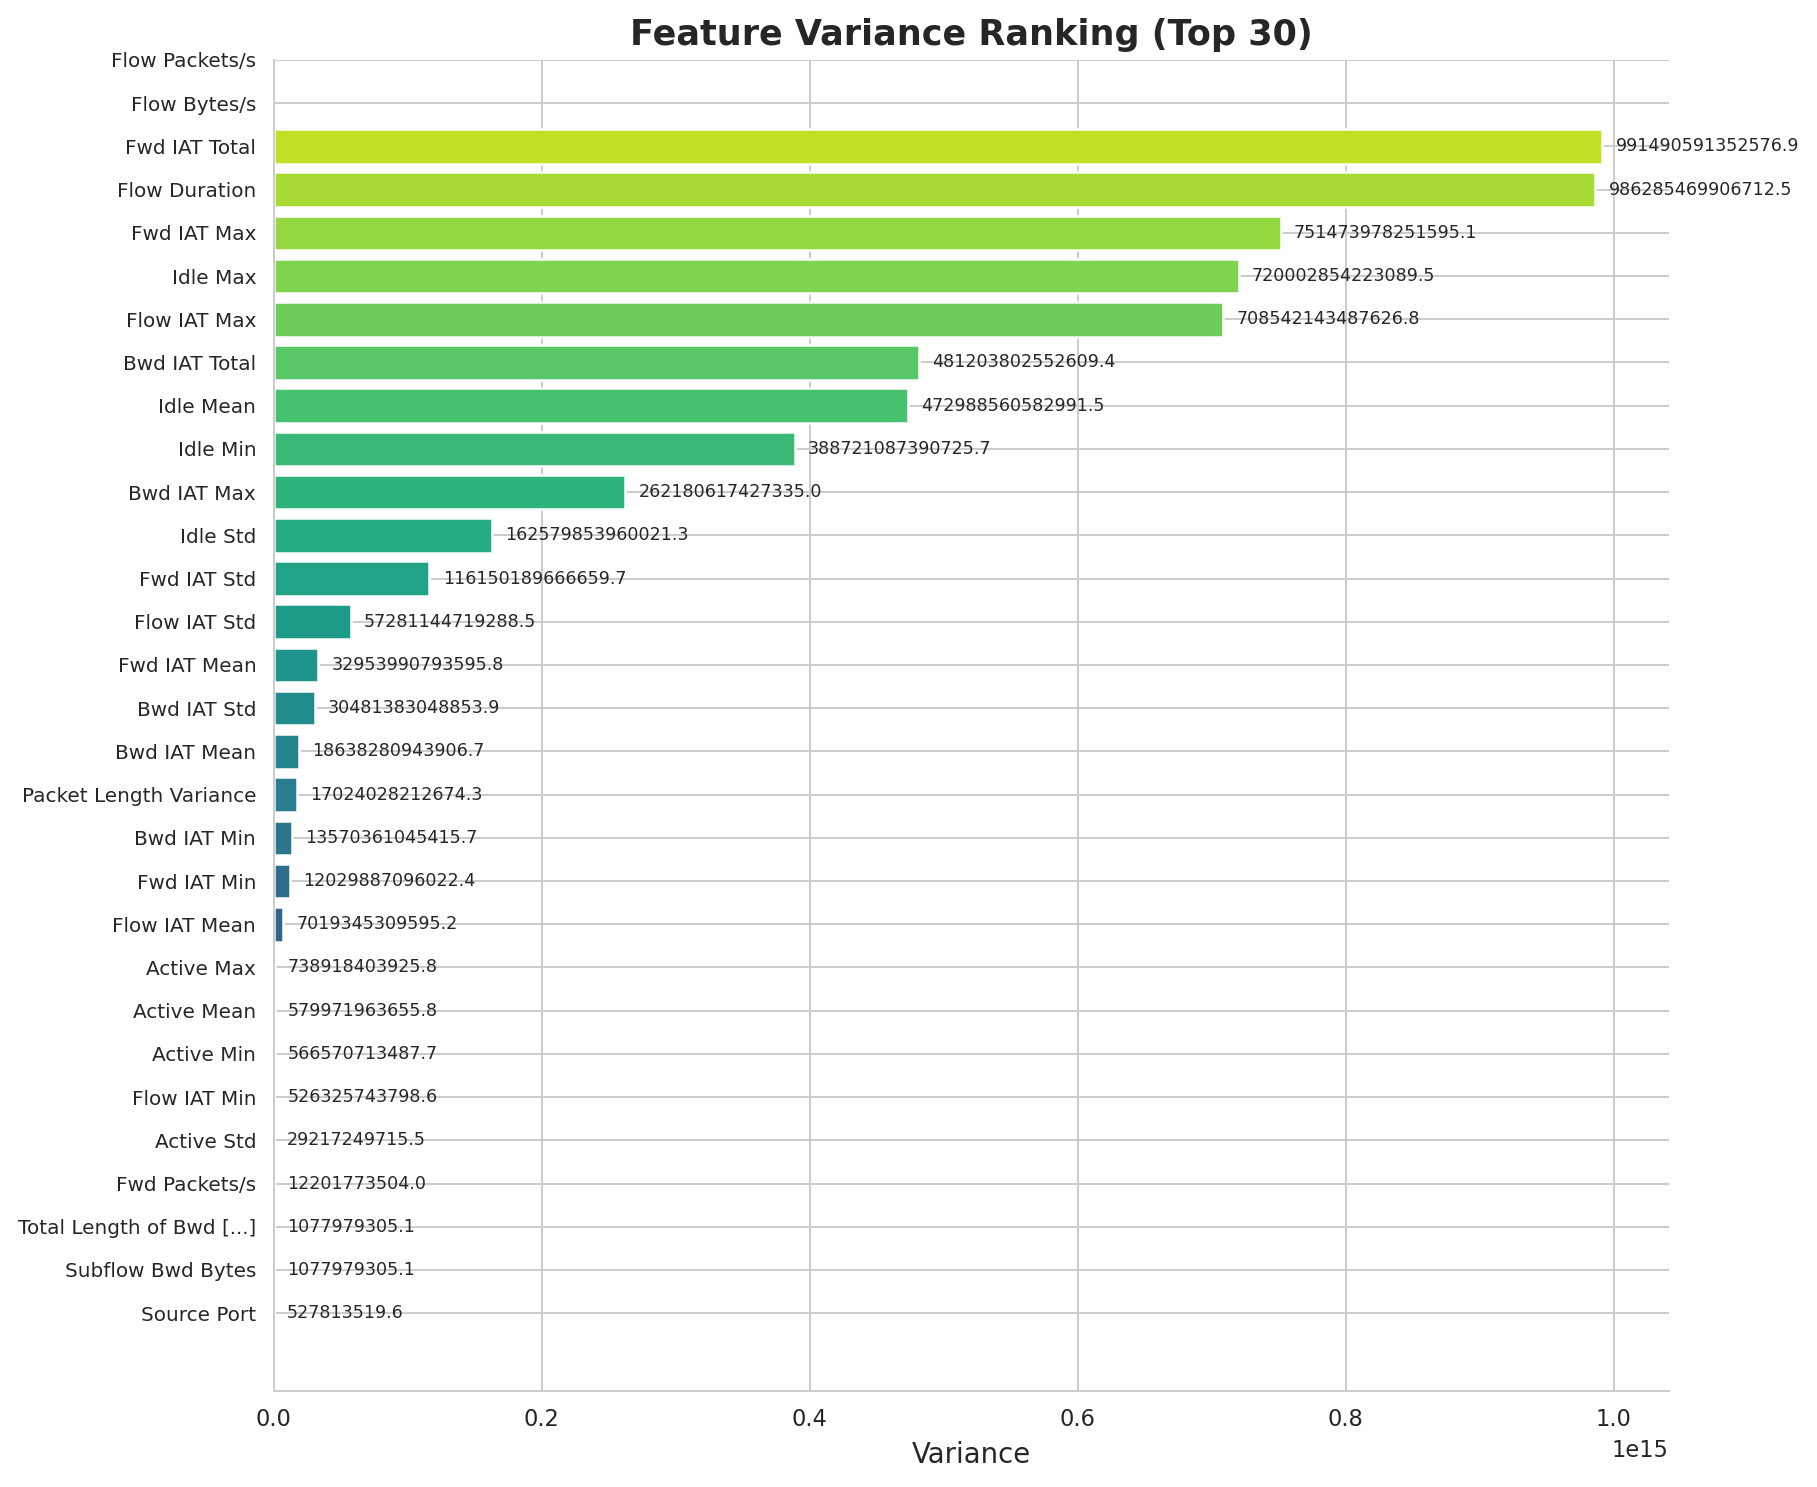


--- 10 Pca Projection ---


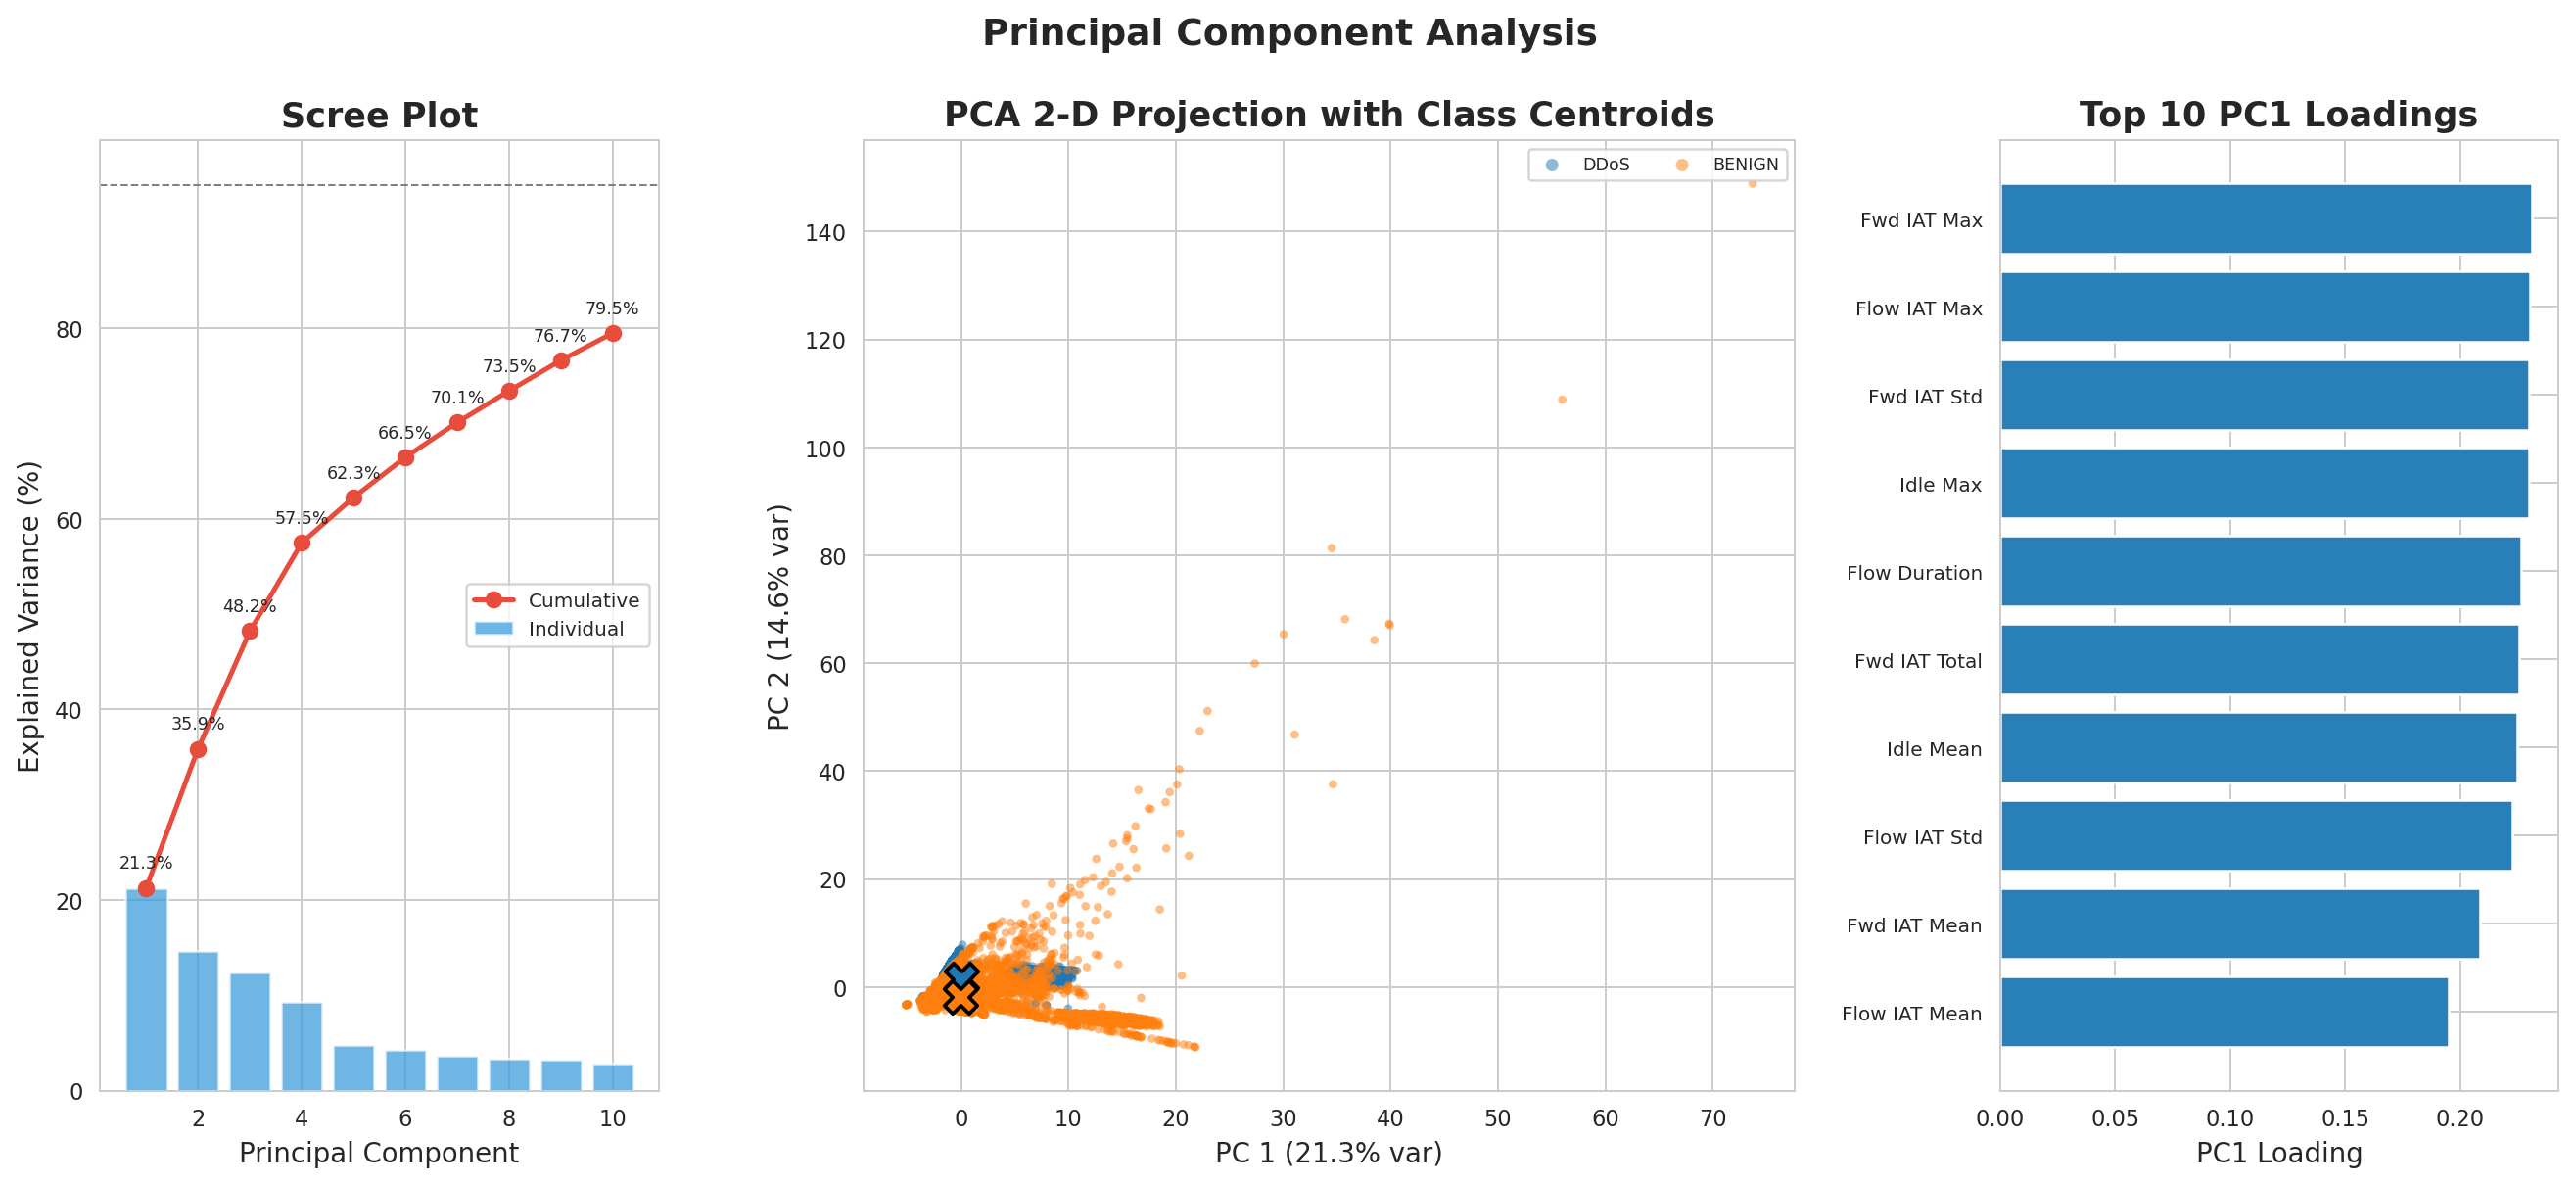


--- 11 Tsne Projection ---


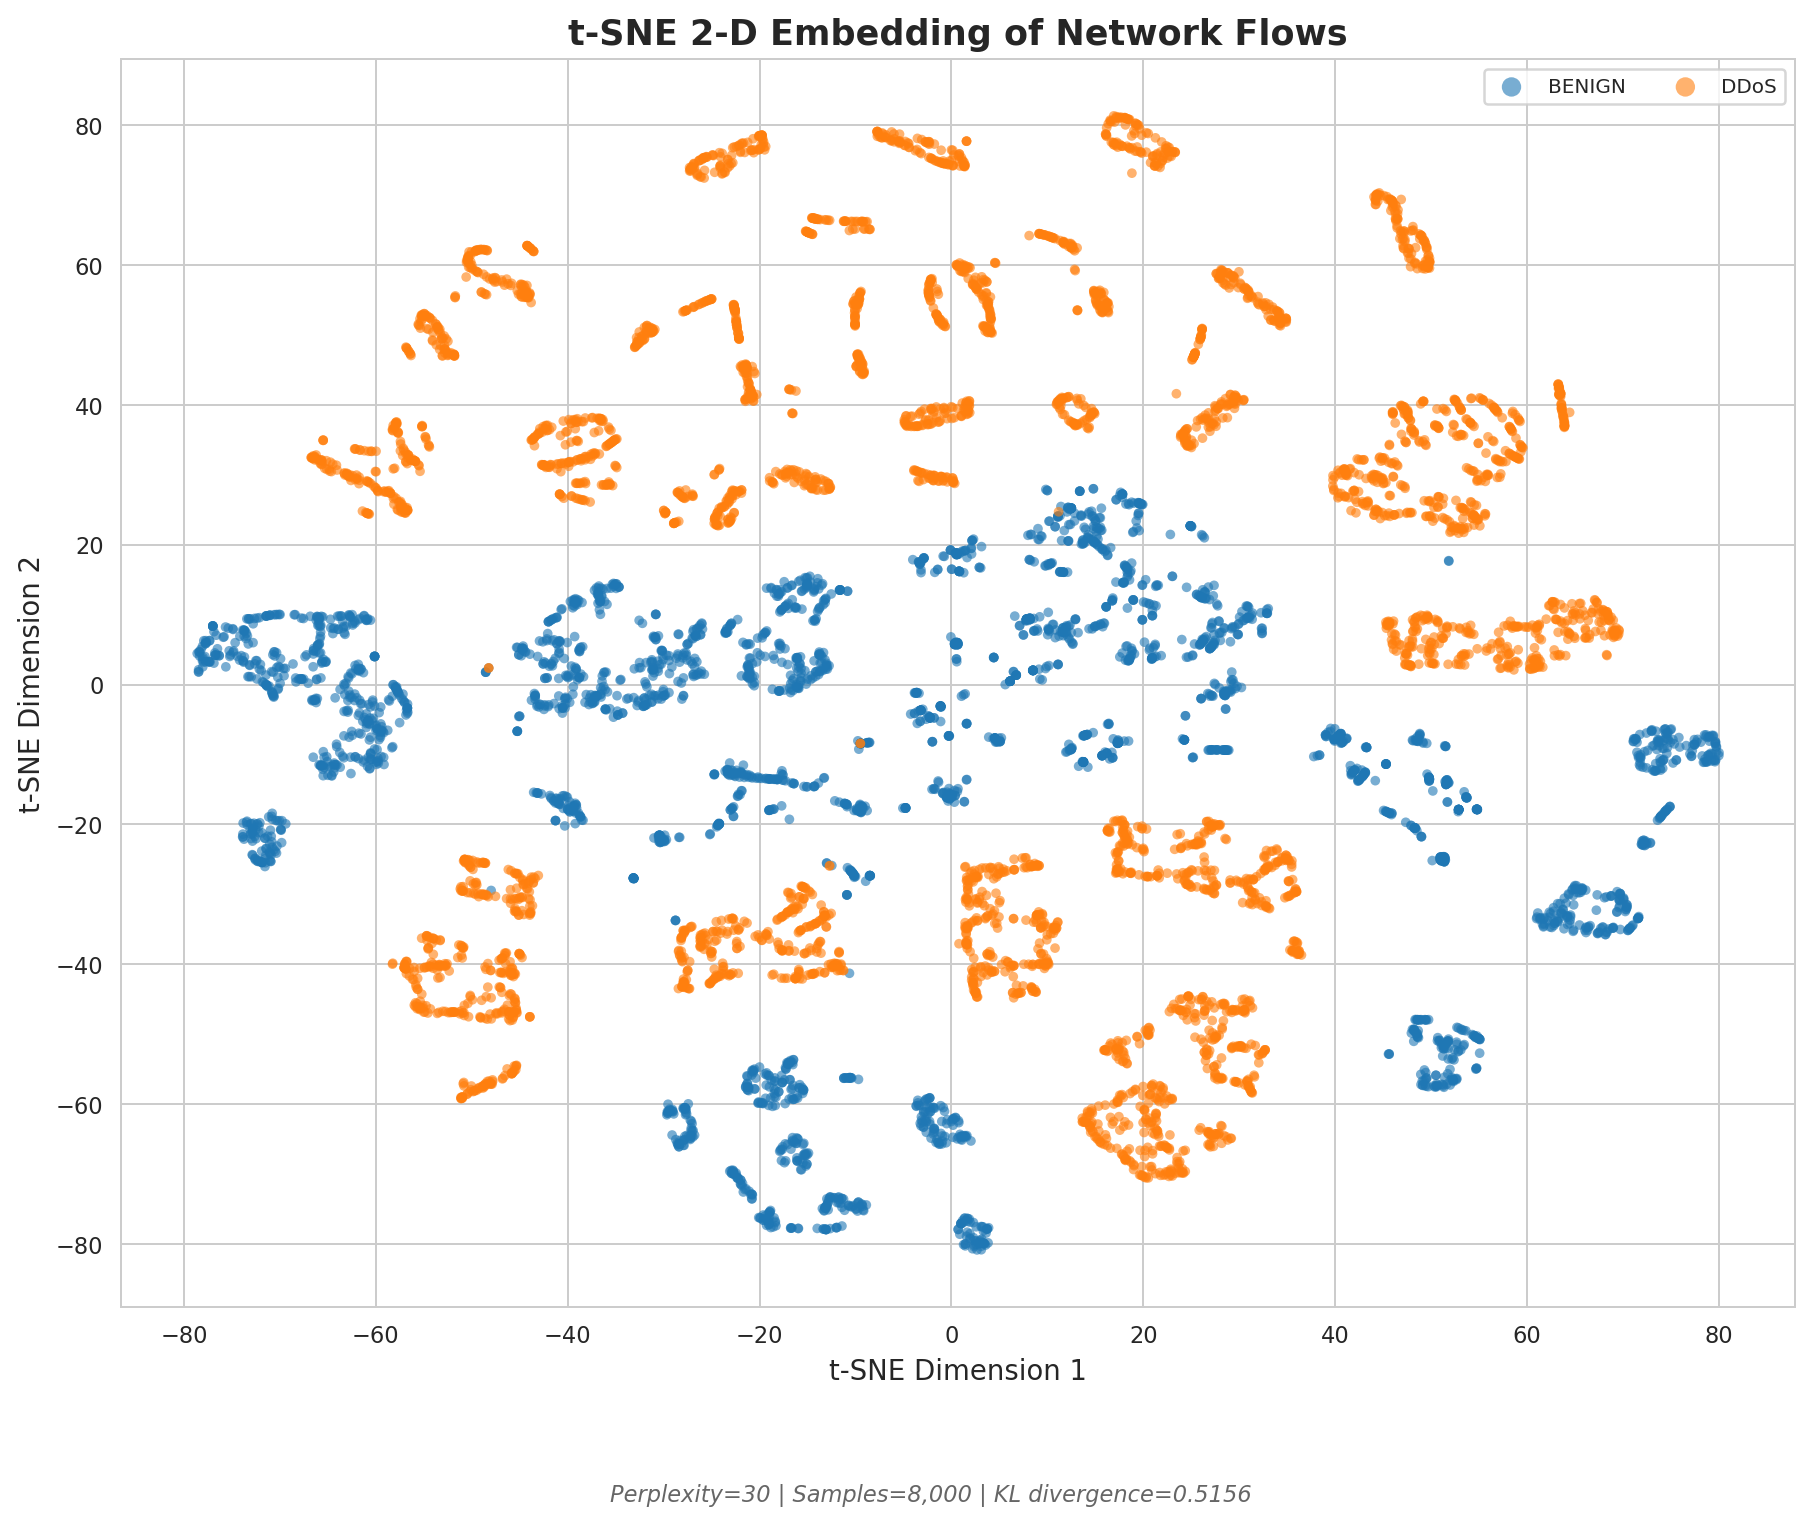


--- 12 Pairplot ---


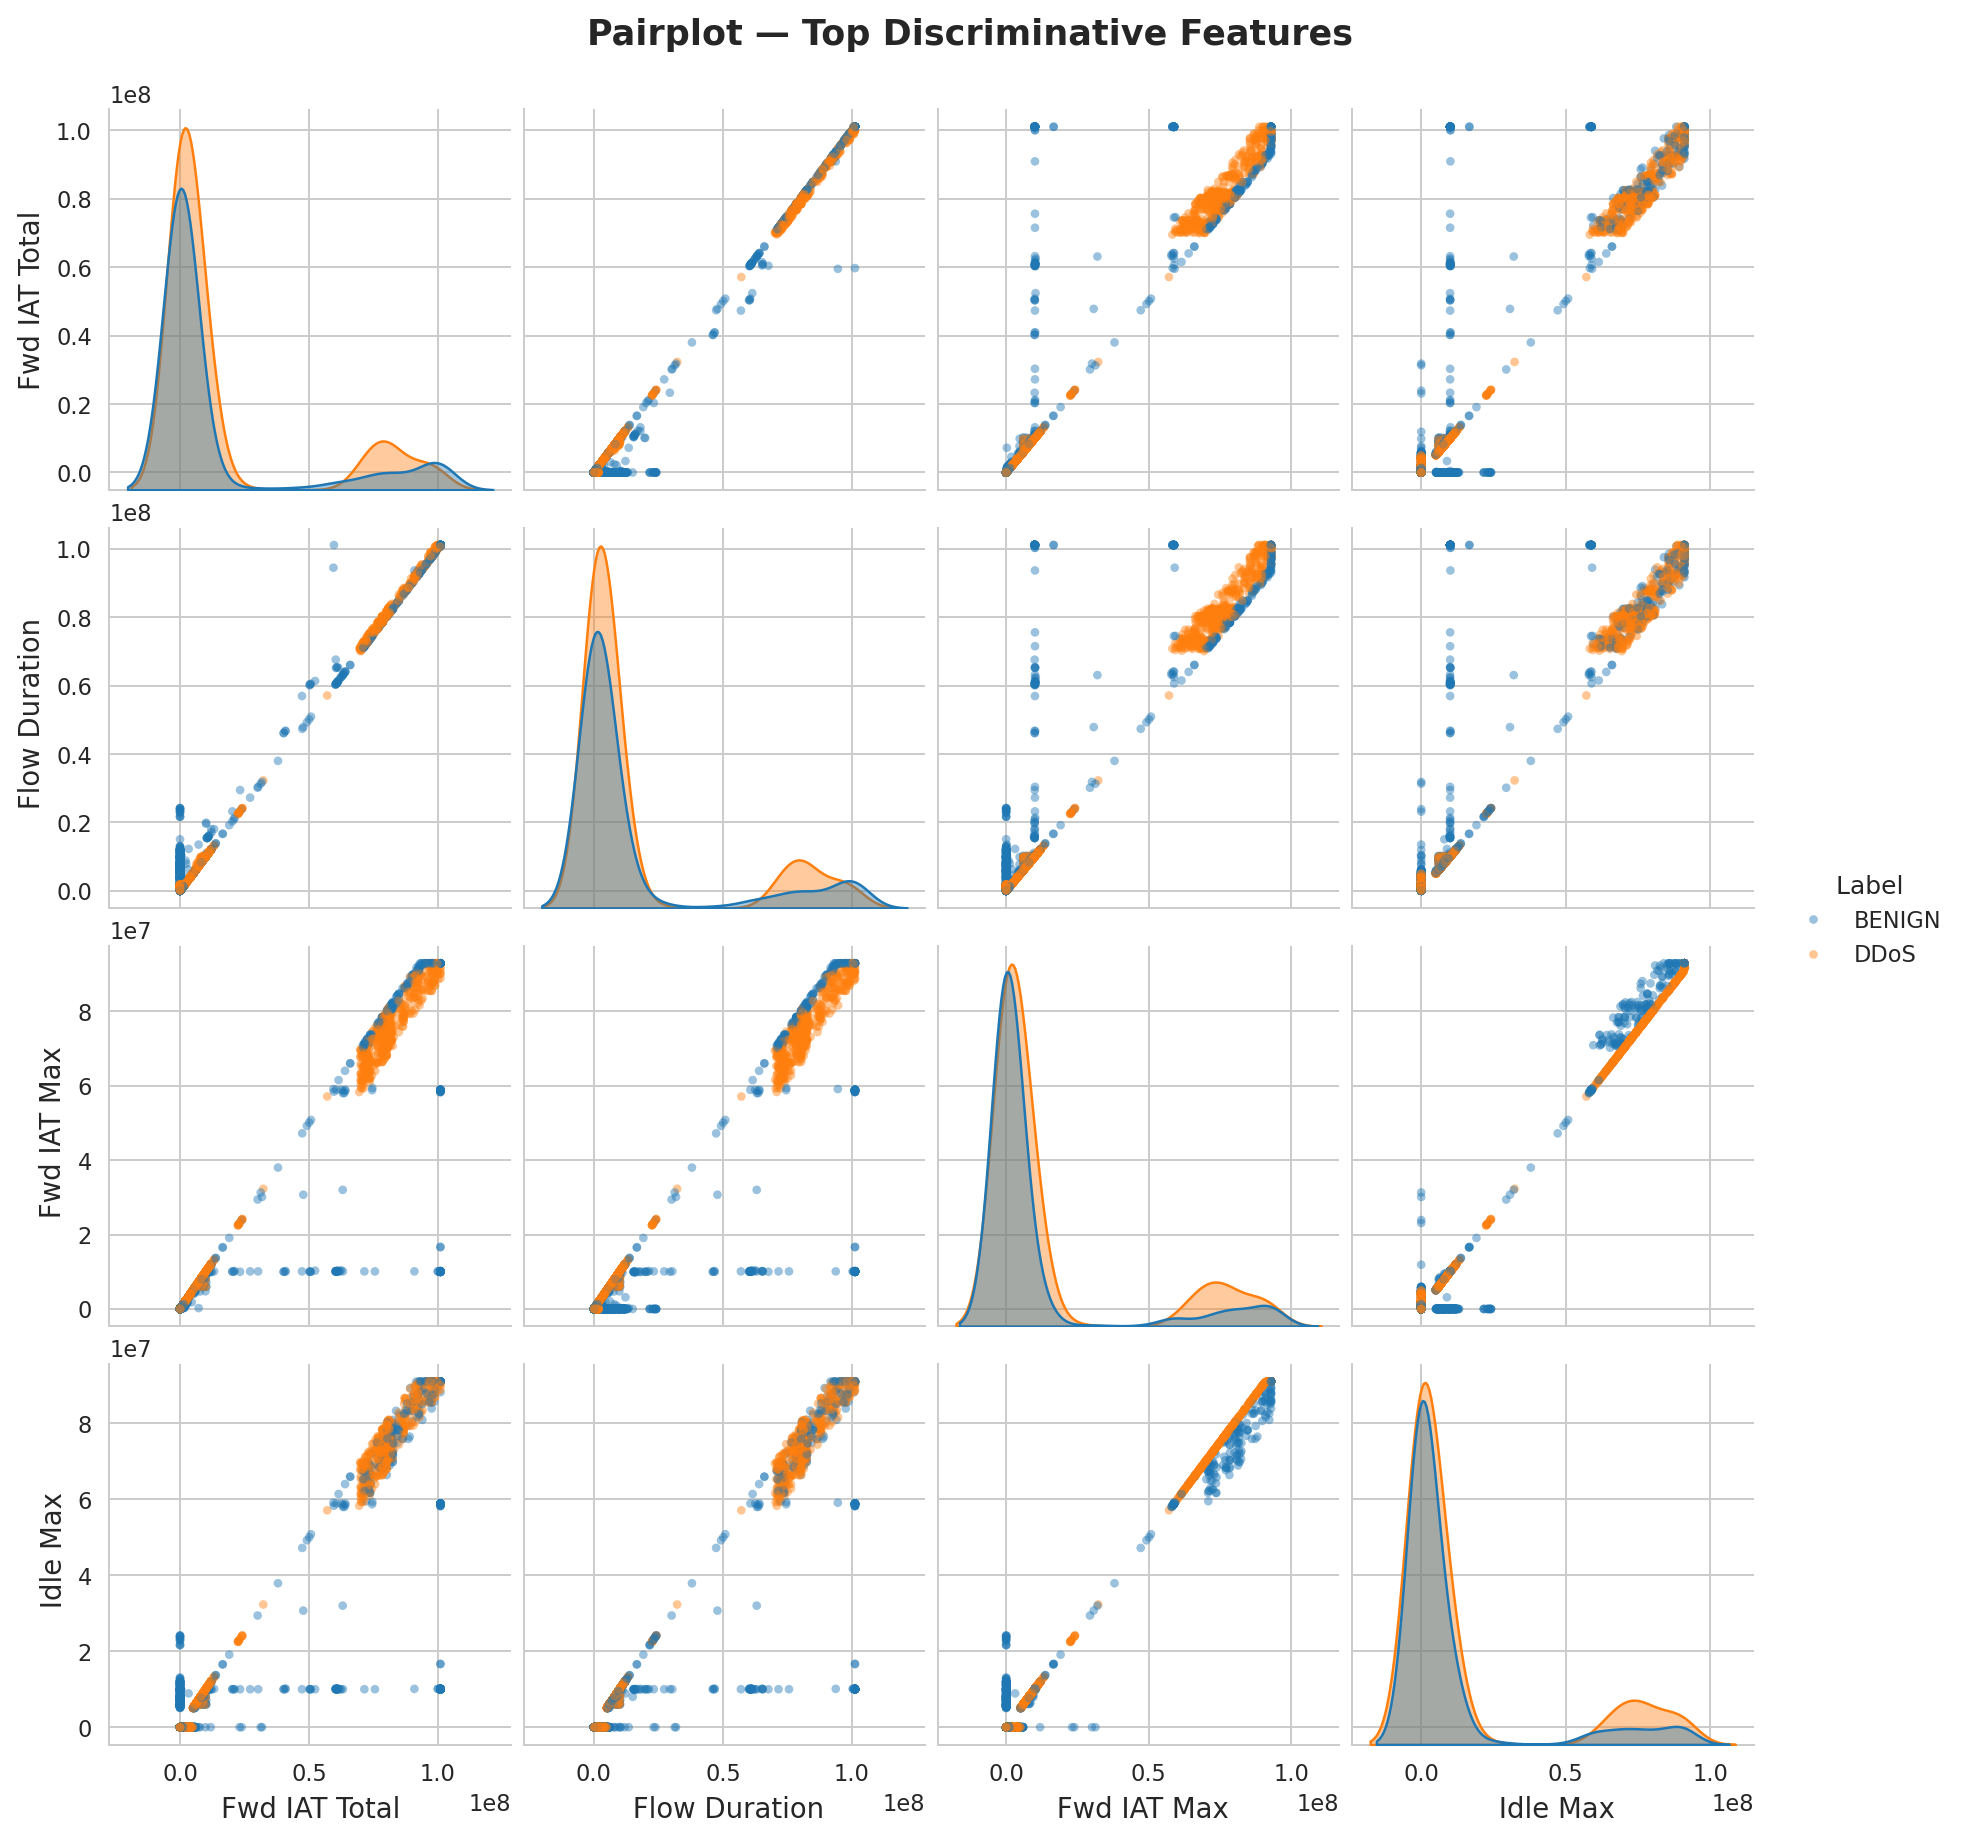

In [5]:
from pathlib import Path
from IPython.display import display, Image as IPImage

eda_path = Path('/content/sares/advanced_ddos_detection/reports/eda')
figures = sorted(eda_path.glob('*.png'))

print(f"Displaying {len(figures)} EDA figures:\n")
for fig_path in figures:
    title = fig_path.stem.replace('_', ' ').title()
    print(f'--- {title} ---')
    display(IPImage(filename=str(fig_path), width=900))
    print()

---
## Step 5 / 10 — Data Preprocessing

Pipeline: **encode target -> drop columns -> clean inf/NaN -> train/test split -> impute -> outlier handling -> scale -> SMOTE balance**

> All imputation and scaling are fit on training set only to prevent data leakage.

In [6]:
%%time
print("="*60)
print("  STEP 5/10 — Data Preprocessing")
print("="*60)

from advanced_ddos_detection.utils.config import load_config
from advanced_ddos_detection.utils.logger import setup_logger
from advanced_ddos_detection.data.loader import DataLoader
from advanced_ddos_detection.data.preprocessor import DataPreprocessor
from advanced_ddos_detection.evaluation.evaluator import ModelEvaluator

cfg = load_config()
setup_logger(cfg)
cfg['data']['file_path'] = csv_path

print("  [1/4] Loading data...")
loader = DataLoader(cfg)
df_raw = loader.load()

print("  [2/4] Encoding & cleaning...")
print("  [3/4] Train/test split...")
print("  [4/4] Scaling & balancing...")
preprocessor = DataPreprocessor(cfg)
split = preprocessor.run(df_raw)

n_classes = len(np.unique(split.y_train))
evaluator = ModelEvaluator(cfg)

print(f"\n  Results:")
print(f"    Features:      {len(split.feature_names)}")
print(f"    Train samples: {split.X_train.shape[0]:,}")
print(f"    Test samples:  {split.X_test.shape[0]:,}")
print(f"    Classes:       {n_classes}")
if split.label_encoder is not None:
    print(f"    Class names:   {list(split.label_encoder.classes_)}")
print(f"    Scaler:        {type(split.scaler).__name__}")

print("\n" + "✅ Step 5/10 complete — data preprocessed.")

  STEP 5/10 — Data Preprocessing
  [1/4] Loading data...
2026-04-05 04:27:35 | INFO     | advanced_ddos_detection.data.loader | Loading dataset from /content/sares/advanced_ddos_detection/data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2026-04-05 04:27:37 | INFO     | advanced_ddos_detection.data.loader | Loaded 225745 rows × 85 columns
2026-04-05 04:27:38 | INFO     | advanced_ddos_detection.data.loader | Missing values: 4 | Infinite values: 64
2026-04-05 04:27:38 | INFO     | advanced_ddos_detection.data.loader | Label distribution:
 Label
DDoS      128027
BENIGN     97718
  [2/4] Encoding & cleaning...
  [3/4] Train/test split...
  [4/4] Scaling & balancing...
2026-04-05 04:27:38 | INFO     | advanced_ddos_detection.data.preprocessor | Dropped configured columns: ['Flow ID', ' Source IP', ' Destination IP', ' Timestamp']
2026-04-05 04:27:38 | INFO     | advanced_ddos_detection.data.preprocessor | Encoded target classes: ['BENIGN', 'DDoS']
2026-04-05 04:27:39 | INFO     | advan

---
## Step 6 / 10 — Train ML Models

Training **7 ML models** with GridSearchCV hyperparameter tuning.
Each model shows real-time progress and metrics when done.

| # | Model | Tuning Parameters |
|---|-------|-------------------|
| 1 | Random Forest | n_estimators, max_depth |
| 2 | XGBoost | learning_rate, n_estimators, max_depth |
| 3 | LightGBM | learning_rate, n_estimators, num_leaves |
| 4 | CatBoost | learning_rate, iterations, depth |
| 5 | Gradient Boosting | learning_rate, n_estimators, max_depth |
| 6 | Logistic Regression | C, solver |
| 7 | KNN | n_neighbors, weights |

In [7]:
%%time
from advanced_ddos_detection.models.ml_models import SklearnModel
import time as _time

print("="*60)
print("  STEP 6/10 — Train ML Models")
print("="*60)

ml_model_configs = [
    ('random_forest',       {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20, 30]}),
    ('xgboost',             {'learning_rate': [0.01, 0.1, 0.3], 'n_estimators': [50, 100, 200], 'max_depth': [3, 6, 10]}),
    ('lightgbm',            {'learning_rate': [0.01, 0.1, 0.3], 'n_estimators': [50, 100, 200], 'num_leaves': [31, 63, 127]}),
    ('catboost',            {'learning_rate': [0.01, 0.1, 0.3], 'iterations': [100, 200], 'depth': [4, 6, 8]}),
    ('gradient_boosting',   {'learning_rate': [0.01, 0.1, 0.3], 'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 7]}),
    ('logistic_regression', {'C': [0.01, 0.1, 1.0, 10.0], 'solver': ['lbfgs']}),
    ('knn',                 {'n_neighbors': [3, 5, 7, 11], 'weights': ['uniform', 'distance']}),
]

total_ml = len(ml_model_configs)
trained_ml = {}  # name -> model object

for idx, (name, params) in enumerate(ml_model_configs, 1):
    print(f"\n  [{idx}/{total_ml}] Training {name}...")
    t0 = _time.time()

    model = SklearnModel(name, params, cfg['tuning'])
    model.fit(split.X_train, split.y_train)
    y_pred = model.predict(split.X_test)

    # Get probabilities for ROC/PR if available
    y_proba = None
    if hasattr(model.model, 'predict_proba'):
        try:
            y_proba = model.model.predict_proba(split.X_test)
        except Exception:
            pass

    metrics = evaluator.evaluate(name, split.y_test, y_pred,
                                 y_proba=y_proba, best_params=model.get_params())
    elapsed = _time.time() - t0

    trained_ml[name] = model
    bar = chr(9608) * idx + chr(9617) * (total_ml - idx)
    print(f"    Done ({elapsed:.1f}s) | Accuracy: {metrics['accuracy']:.4f} | F1: {metrics['f1_weighted']:.4f}")
    print(f"    Best params: {model.get_params()}")
    print(f"    Progress: {bar} {idx}/{total_ml}")

print(f"\n{'='*60}")
print(f"  Step 6/10 complete — all {total_ml} ML models trained.")
print(f"{'='*60}")

  STEP 6/10 — Train ML Models

  [1/7] Training random_forest...
2026-04-05 04:28:39 | INFO     | advanced_ddos_detection.models.ml_models | [random_forest] Starting GridSearchCV (cv=5, scoring=f1_weighted)


KeyboardInterrupt: 

---
## Step 7 / 10 — Train Deep Learning Models

Training **3 DL architectures** with early stopping and learning rate scheduling.

| # | Model | Architecture |
|---|-------|---------------|
| 1 | MLP | Dense layers with BatchNorm + Dropout |
| 2 | LSTM | LSTM layers treating features as sequences |
| 3 | CNN1D | 1D Convolutions over feature vectors |

In [8]:
%%time
from advanced_ddos_detection.models.dl_model import DeepLearningModel, LSTMModel, CNN1DModel

print("="*60)
print("  STEP 7/10 — Train Deep Learning Models")
print("="*60)

n_features = split.X_train.shape[1]

dl_model_configs = [
    ('DL_MLP',   DeepLearningModel),
    ('DL_LSTM',  LSTMModel),
    ('DL_CNN1D', CNN1DModel),
]

total_dl = len(dl_model_configs)
trained_dl = {}  # name -> model object

for idx, (name, ModelClass) in enumerate(dl_model_configs, 1):
    print(f"\n  [{idx}/{total_dl}] Training {name}...")
    t0 = _time.time()

    dl_model = ModelClass(cfg, n_features=n_features, n_classes=n_classes)
    dl_model.build()

    # Show architecture summary
    param_count = dl_model.model.count_params()
    print(f"    Architecture: {param_count:,} parameters")
    print(f"    Training... (early stopping enabled)")

    dl_model.fit(split.X_train, split.y_train)
    y_pred = dl_model.predict(split.X_test)

    # Get probabilities for ROC/PR
    y_proba_dl = None
    try:
        X_in = split.X_test
        if name in ('DL_LSTM', 'DL_CNN1D'):
            X_in = X_in.reshape(X_in.shape[0], X_in.shape[1], 1)
        y_proba_dl = dl_model.model.predict(X_in, verbose=0)
    except Exception:
        pass

    metrics = evaluator.evaluate(name, split.y_test, y_pred,
                                 y_proba=y_proba_dl, best_params=dl_model.get_params())
    elapsed = _time.time() - t0

    trained_dl[name] = dl_model
    epochs_ran = dl_model.get_params().get('epochs_ran', '?')
    bar = chr(9608) * idx + chr(9617) * (total_dl - idx)
    print(f"    Done ({elapsed:.1f}s) | {epochs_ran} epochs | Accuracy: {metrics['accuracy']:.4f} | F1: {metrics['f1_weighted']:.4f}")
    print(f"    Progress: {bar} {idx}/{total_dl}")

print(f"\n{'='*60}")
print(f"  Step 7/10 complete — all {total_dl} DL models trained.")
print(f"{'='*60}")

  STEP 7/10 — Train Deep Learning Models

  [1/3] Training DL_MLP...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2026-04-05 04:43:15 | INFO     | advanced_ddos_detection.models.dl_model | MLP model built: ['dense', 'batch_normalization', 'dropout', 'dense_1', 'batch_normalization_1', 'dropout_1', 'dense_2', 'batch_normalization_2', 'dropout_2', 'dense_3']
    Architecture: 20,386 parameters
    Training... (early stopping enabled)
2026-04-05 04:43:15 | INFO     | advanced_ddos_detection.models.dl_model | Training MLP for up to 100 epochs …


KeyboardInterrupt: 

---
## Step 8 / 10 — Ensemble Learning

Build **Voting** and **Stacking** ensembles from the best trained ML models.

| Method | How it works |
|--------|-------------|
| **Hard Voting** | Each base model casts one vote; majority wins |
| **Stacking** | A meta-learner (Logistic Regression) learns to combine base model predictions via cross-validation |

> Only sklearn-compatible models are used as base estimators (DL models are excluded from ensembles).

In [9]:
%%time
from advanced_ddos_detection.models.ensemble import EnsembleModel

print("="*60)
print("  STEP 8/10 — Ensemble Learning")
print("="*60)

# Select base models for ensembles (all trained ML models)
base_models = list(trained_ml.values())
print(f"\n  Base models ({len(base_models)}): {[m.name for m in base_models]}")

ensemble_types = ['voting', 'stacking']
total_ens = len(ensemble_types)
trained_ensembles = {}

for idx, ens_type in enumerate(ensemble_types, 1):
    print(f"\n  [{idx}/{total_ens}] Training {ens_type.title()} Ensemble...")
    t0 = _time.time()

    ens_model = EnsembleModel(
        ensemble_type=ens_type,
        base_models=base_models,
        cfg=cfg,
    )
    ens_model.build()
    ens_model.fit(split.X_train, split.y_train)
    y_pred_ens = ens_model.predict(split.X_test)

    # Get probabilities if available (soft voting / stacking)
    y_proba_ens = None
    if hasattr(ens_model.model, 'predict_proba'):
        try:
            y_proba_ens = ens_model.model.predict_proba(split.X_test)
        except Exception:
            pass

    ens_name = f"Ensemble_{ens_type}"
    metrics = evaluator.evaluate(ens_name, split.y_test, y_pred_ens,
                                 y_proba=y_proba_ens, best_params=ens_model.get_params())
    elapsed = _time.time() - t0

    trained_ensembles[ens_name] = ens_model
    bar = chr(9608) * idx + chr(9617) * (total_ens - idx)
    print(f"    Done ({elapsed:.1f}s) | Accuracy: {metrics['accuracy']:.4f} | F1: {metrics['f1_weighted']:.4f}")
    print(f"    Base models used: {ens_model.get_params()['base_models']}")
    print(f"    Progress: {bar} {idx}/{total_ens}")

print(f"\n{'='*60}")
print(f"  Step 8/10 complete — {total_ens} ensemble models trained.")
print(f"{'='*60}")

  STEP 8/10 — Ensemble Learning

  Base models (0): []

  [1/2] Training Voting Ensemble...


ValueError: Need ≥2 base estimators for ensemble, got 0

---
## Step 9 / 10 — Model Comparison & Evaluation

Compare all trained models (7 ML + 3 DL + 2 Ensembles) with:
- Summary metrics table
- Classification reports
- Confusion matrices
- ROC and Precision-Recall curves
- Side-by-side comparison bar chart

In [10]:
print("="*60)
print("  STEP 9/10 — Model Comparison & Evaluation")
print("="*60)

# --- Summary table ---
print("\n  [1/5] Summary Table")
summary = evaluator.summary_table()
display(summary)

# --- Best model ---
best_row = summary.iloc[0]
print(f"\n  Best Model: {best_row['Model']}")
print(f"     Accuracy:     {best_row.get('accuracy', 'N/A')}")
print(f"     F1 (weighted): {best_row.get('f1_weighted', 'N/A')}")

  STEP 9/10 — Model Comparison & Evaluation

  [1/5] Summary Table


KeyError: 'F1'

In [ ]:
# --- Classification reports ---
print("  [2/5] Classification Reports")
evaluator.print_reports()

In [ ]:
# --- Confusion matrices ---
print("  [3/5] Confusion Matrices")
reports_dir = cfg.get('output', {}).get('reports_dir', 'reports')
evaluator.plot_confusion_matrices(save_dir=reports_dir)

In [ ]:
# --- ROC and PR curves ---
print("  [4/5] ROC & Precision-Recall Curves")
evaluator.plot_roc_curves(save_dir=reports_dir)
evaluator.plot_pr_curves(save_dir=reports_dir)

In [ ]:
# --- Comparison bar chart ---
print("  [5/5] Model Comparison Bar Chart")
evaluator.plot_comparison_bar(save_dir=reports_dir)

print("\n" + "✅ Step 9/10 complete — all evaluation artifacts generated.")

---
## Step 10 / 10 — Save All Trained Models

Persist every trained model, scaler, and label encoder to disk.
- ML models: `.joblib` files
- DL models: Keras `.keras` format
- Ensemble models: `.joblib` files
- Each model gets a `metadata.json` with metrics and feature names

In [ ]:
%%time
from advanced_ddos_detection.utils.persistence import ModelPersistence

print("="*60)
print("  STEP 10/10 — Save All Trained Models")
print("="*60)

persistence = ModelPersistence(cfg)
saved_count = 0
total_to_save = len(trained_ml) + len(trained_dl) + len(trained_ensembles) + 2  # +2 for scaler & encoder

# --- Save scaler ---
saved_count += 1
print(f"\n  [{saved_count}/{total_to_save}] Saving scaler...")
if split.scaler is not None:
    persistence.save_scaler(split.scaler)
    print(f"    Saved ({type(split.scaler).__name__})")

# --- Save label encoder ---
saved_count += 1
print(f"  [{saved_count}/{total_to_save}] Saving label encoder...")
if split.label_encoder is not None:
    persistence.save_label_encoder(split.label_encoder)
    print(f"    Saved ({list(split.label_encoder.classes_)})")

# --- Save ML models ---
for name, model in trained_ml.items():
    saved_count += 1
    print(f"  [{saved_count}/{total_to_save}] Saving {name}...")
    if model.model is not None:
        persistence.save_sklearn_model(
            model.model, name,
            metrics=evaluator.results.get(name),
            feature_names=split.feature_names,
        )
        print(f"    Saved (.joblib)")

# --- Save DL models ---
for name, model in trained_dl.items():
    saved_count += 1
    print(f"  [{saved_count}/{total_to_save}] Saving {name}...")
    if model.model is not None:
        persistence.save_keras_model(
            model.model, name,
            metrics=evaluator.results.get(name),
            feature_names=split.feature_names,
        )
        print(f"    Saved (.keras)")

# --- Save Ensemble models ---
for name, model in trained_ensembles.items():
    saved_count += 1
    print(f"  [{saved_count}/{total_to_save}] Saving {name}...")
    if model.model is not None:
        persistence.save_sklearn_model(
            model.model, name,
            metrics=evaluator.results.get(name),
            feature_names=split.feature_names,
        )
        print(f"    Saved (.joblib)")

print(f"\n{'='*60}")
print(f"  Step 10/10 complete — {saved_count} items saved.")
print(f"{'='*60}")

In [ ]:
# --- Verify saved models ---
print("  Saved Models Inventory:\n")
saved = persistence.list_saved_models()
for i, model_name in enumerate(saved, 1):
    meta = persistence.load_metadata(model_name)
    mtype = meta.get('model_type', '?')
    saved_at = meta.get('saved_at', '?')
    print(f"    {i:>2}. {model_name:25s}  type={mtype:20s}  saved_at={saved_at}")

print(f"\n  Total: {len(saved)} models saved to {persistence.models_dir}")

In [ ]:
# --- Quick verification: load saved model and predict ---
print("  Verification — load saved model and predict:\n")

best_model_name = summary.iloc[0]['Model']

# Try to load best model (ML + ensemble models use joblib, DL uses keras)
if best_model_name in trained_ml or best_model_name in trained_ensembles:
    loaded = persistence.load_sklearn_model(best_model_name)
else:
    loaded = persistence.load_keras_model(best_model_name)

le = persistence.load_label_encoder()

sample = split.X_test[:5]
preds = loaded.predict(sample)
if hasattr(preds[0], '__len__'):  # DL softmax output
    preds = np.argmax(preds, axis=1)
labels = le.inverse_transform(preds) if le is not None else preds
true_labels = le.inverse_transform(split.y_test[:5]) if le is not None else split.y_test[:5]

print(f"  Model: {best_model_name} (loaded from disk)\n")
for i, (pred, true) in enumerate(zip(labels, true_labels)):
    match = 'OK' if pred == true else 'MISS'
    print(f"    Sample {i}: predicted={str(pred):12s}  actual={str(true):12s}  {match}")

correct = sum(p == t for p, t in zip(labels, true_labels))
print(f"\n  Verified: {correct}/{len(labels)} correct predictions from saved model.")

---
## Push Results to GitHub

The notebook file becomes very large after training (embedded plots, SHAP images, model outputs).
The cell below **strips outputs** from the notebook before pushing to stay under GitHub's 100MB file limit.
Reports and saved models are committed separately as individual files.

In [12]:
# Push results to GitHub
# Strips large notebook outputs first to stay under GitHub's file size limit

import subprocess, os

os.chdir('/content/sares')

# 1. Pull latest changes first
subprocess.run(['git', 'pull', '--rebase'], check=True)

# 2. Install nbstripout and strip notebook outputs
subprocess.run(['pip', 'install', '-q', 'nbstripout'], check=True)
subprocess.run(['nbstripout', '/content/sares/colab_run.ipynb'], check=True)
print('Notebook outputs stripped.')

# 3. Stage everything
subprocess.run(['git', 'add', '-A'], check=False)

# 4. Commit (skip if nothing changed)
ret = subprocess.run(['git', 'diff', '--cached', '--quiet'])
if ret.returncode != 0:
    subprocess.run(['git', 'commit', '-m', 'Add training results from Colab'], check=True)
    subprocess.run(['git', 'push'], check=True)
    print('Push complete!')
else:
    print('Nothing new to commit — everything is already up to date.')
